# **Binary Stroke Prediction**

By: LAB-P3-11

Team members:
1. Timothy Chia Kai Lun (2501530)
2. Sitt Min Niang (2502873)
3. Tan De Xuan, Cody (2503322)
4. Guo Youyan (2502970)
5. Patrick Koh Moh Yan (2501365)

Dataset link: [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset/data)

# 1. Business Understanding

## 1.1 Problem Objective

We aim to develop a binary classification model to predict whether an individual is at risk of experiencing a stroke based on their demographic, lifestyle, and clinical characteristics.

**Target Variable**: Stroke occurrence (1 = stroke occurred, 0 = no stroke)

**Task Type**: Binary Classification (Supervised Learning)

### Why This Matters

**Healthcare Impact:**
- Strokes are the second leading cause of death globally, accounting for approximately 11% of total deaths (WHO, 2022)
- Early identification of high-risk individuals enables preventive interventions
- Stroke treatment is significantly more effective when administered within the first few hours of onset
- Healthcare systems face substantial economic burden from stroke treatment and post-stroke care

**Preventive Care Value:**
- Many stroke risk factors (hypertension, glucose levels, smoking) are modifiable through lifestyle changes and medical intervention
- Proactive identification allows for targeted screening programs and patient education
- Cost-effective prevention is preferable to expensive emergency treatment and long-term rehabilitation

## 1.2 Decision Context and Use Cases

### Primary Use Case: Clinical Risk Screening

**Context**: Routine health assessments at primary care facilities, annual check-ups, or health screening programs

**Decision Point**: Should this patient be:
1. Referred for comprehensive cardiovascular assessment?
2. Enrolled in a stroke prevention program?
3. Scheduled for more frequent monitoring?
4. Provided with targeted lifestyle intervention recommendations?

**Stakeholders**:
- **Healthcare Providers**: General practitioners, nurses conducting health screenings
- **Patients**: Individuals aged 30+ undergoing routine health assessments
- **Healthcare Administrators**: Public health officials planning preventive care programs

**Decision Process**:
```
Patient Assessment → Risk Prediction → Risk Stratification → Intervention Decision
```

### How Model Output Would Be Used

**High-Risk Prediction (Positive Class)**:
- Trigger referral to specialist (cardiologist/neurologist)
- Initiate intensive monitoring program
- Recommend immediate lifestyle modifications
- Consider preventive medication (antiplatelet therapy, statins)
- Schedule follow-up within 3-6 months

**Low-Risk Prediction (Negative Class)**:
- Continue routine annual check-ups
- Provide general health maintenance advice
- Monitor modifiable risk factors during standard visits

**Important Note**: This model serves as a screening tool to support clinical decision-making, NOT as a diagnostic tool. Final decisions must always involve clinical judgment and additional diagnostic procedures.

## 1.3 Success Criteria

### Primary Success Metrics

**1. Model Performance (Baseline Assessment)**
- **Recall (Sensitivity)**: Primary metric due to class imbalance and cost of false negatives
  - Target: >60% for baseline models
  - Rationale: Missing a high-risk patient (false negative) has severe consequences
  
- **Precision**: Secondary metric to manage false alarm rate
  - Target: >40% for baseline models
  - Rationale: Too many false positives can overwhelm healthcare resources
  
- **F1-Score**: Balance between precision and recall
  - Target: >0.50 for baseline models

- **ROC-AUC**: Overall discriminative ability
  - Target: >0.70 for baseline models (fair to good performance)

**2. Interpretability**
- Model predictions must be explainable to healthcare providers
- Feature importance should align with known clinical risk factors (age, hypertension, heart disease)
- Baseline models should provide clear decision boundaries

**3. Feasibility Assessment**
- Baseline models should demonstrate above-random performance
- Data quality and quantity should be sufficient for meaningful predictions
- Identified limitations should inform Stage 2 improvements

### What Success Does NOT Mean at Stage 1
- **Not**: Achieving state-of-the-art performance (this is baseline only)
- **Not**: Production-ready deployment
- **Not**: Perfectly balanced precision and recall
- **Focus**: Demonstrating that the problem is tractable and data is suitable

## 1.4 Assumptions

### Data Assumptions
1. **Data Quality**: Patient records are accurately documented and reflect true health status
2. **Representativeness**: Dataset represents the target population for screening (though we acknowledge potential sampling bias)
3. **Feature Completeness**: Available features capture the major known stroke risk factors
4. **Temporal Validity**: Relationships between features and stroke risk remain relatively stable over time

### Modeling Assumptions
1. **Binary Classification Sufficiency**: Risk can be meaningfully categorized as high/low (rather than requiring multiple risk levels)
2. **Feature Independence**: At baseline, we assume features provide independent information (though we know some correlation exists)
3. **Static Risk**: We model current risk based on current features, not progression of risk over time
4. **Generalizability**: Patterns learned from the dataset will generalize to similar populations

### Contextual Assumptions
1. **Clinical Integration**: Healthcare providers will use model output as one input among many in their decision-making
2. **Patient Compliance**: Identified high-risk patients will have access to follow-up care
3. **Resource Availability**: Healthcare system has capacity to handle predicted high-risk cases

## 1.5 Risks and Limitations

### Critical Risks

**1. Class Imbalance Risk (High Impact)**
- **Issue**: Stroke cases are significantly rarer than non-stroke cases in the population
- **Consequence**: Models may achieve high accuracy by simply predicting "no stroke" for everyone
- **Mitigation**:
  - Focus on recall, precision, F1, and ROC-AUC rather than accuracy
  - Document model behavior on minority class
  - Consider stratified sampling in train/test split

**2. False Negative Risk (High Impact)**
- **Issue**: Failing to identify someone who will have a stroke (missed detection)
- **Consequence**: Delayed intervention, potential adverse outcomes for patients
- **Mitigation**:
  - Prioritize recall in evaluation
  - Set appropriate decision thresholds
  - Emphasize that model is screening tool, not final diagnosis

**3. False Positive Risk (Medium Impact)**
- **Issue**: Incorrectly flagging someone as high-risk
- **Consequence**: Unnecessary anxiety, healthcare resource consumption, potential overtreatment
- **Mitigation**:
  - Monitor precision alongside recall
  - Recommend confirmatory testing for positive predictions
  - Communicate uncertainty in risk estimates

**4. Data Leakage Risk (High Impact)**
- **Issue**: Features that are consequences rather than predictors of stroke could leak into the model
- **Consequence**: Artificially inflated performance that doesn't generalize
- **Mitigation**:
  - Careful examination of temporal relationships between features and target
  - Domain knowledge review of each feature
  - Document potential leakage concerns

**5. Missing Data Risk (Medium Impact)**
- **Issue**: BMI and potentially other features have missing values
- **Consequence**: Biased model if missingness is not random
- **Mitigation**:
  - Analyze patterns of missingness
  - Use appropriate imputation strategies
  - Document assumptions about missing data

### Limitations to Acknowledge

**Data Limitations**:
- Dataset size (~5,000 observations) limits model complexity
- Minority class (stroke cases) may be insufficient for robust pattern learning
- Potential selection bias in data collection
- Limited to available features (no genetics, family history, etc.)

**Scope Limitations**:
- Model predicts risk, not timing or severity of potential stroke
- No longitudinal tracking of risk over time
- Limited to individuals with similar demographic profiles as training data
- Cannot capture rapidly changing risk factors

**Methodological Limitations (Stage 1)**:
- Baseline models only, no optimization
- Minimal feature engineering
- No handling of imbalanced data beyond awareness
- Basic evaluation only

## 1.6 Ethical Considerations

### Fairness and Bias
- **Gender Balance**: Ensure model performs equitably across gender categories
- **Age Representation**: Validate that model doesn't systematically disadvantage any age group
- **Socioeconomic Factors**: Work type and residence type could introduce socioeconomic bias

### Privacy and Consent
- Using anonymized medical data
- Results should be communicated with appropriate privacy safeguards
- Patient autonomy in decision-making must be preserved

### Clinical Responsibility
- Model outputs must not replace clinical judgment
- Healthcare providers must be trained in interpreting predictions
- Clear communication about model limitations to prevent misuse

## 1.7 Project Constraints

### Technical Constraints
- Must use classical machine learning models (no deep learning)
- Default hyperparameters only (no tuning)
- Minimal data preparation (basic cleaning only)
- Computation must be feasible on standard hardware

### Time Constraints
- Stage 1 deadline: 13 February 2026
- Focus on establishing feasibility, not optimization

### Resource Constraints
- Limited to publicly available datasets
- Standard Python libraries only
- Free computational resources (Colab)

---

# 2. Data Understanding

**Primary Objectives:**
1. Describe dataset characteristics and structure
2. Explore data distributions and relationships  
3. Assess data quality and identify potential issues
4. Validate assumptions from Business Understanding phase
5. Identify risks and limitations that may impact modelling

**Dataset Context:**
- 5,110 patient records
- 12 columns (11 features + 1 target)
- Binary classification: predict stroke occurrence
- Features: demographics, medical history, lifestyle factors

**Success Criteria:**
- Understand if dataset supports 70% recall target
- Identify class imbalance severity
- Assess feature quality and predictive value
- Document data limitations and risks

## 2.1 Setup and Data Loading

Before conducting any analysis, we import the necessary libraries and load the dataset. We use `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualisation, and `scipy.stats` for statistical testing. The dataset is loaded from a local CSV file containing 5,110 patient records with demographic, clinical, and lifestyle attributes.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pearsonr, ttest_ind
import warnings

# configure settings
plt.style.use('default')
sns.set_palette('husl')
%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

In [ ]:
DATA_DIR = "/content/"
fname = "healthcare-dataset-stroke-data.csv"
# load the stroke dataset
df = pd.read_csv(os.path.join(DATA_DIR, fname))
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
# display data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


## 2.2 Dataset Overview

**Structure:**
- Total records: 5,110
- Total columns: 12

**Features:**
- **Numerical (3)**: `age`, `avg_glucose_level`, `bmi`
- **Categorical (8)**: `gender`, `hypertension`, `heart_disease`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`, `id`
- **Target (1)**: `stroke` (binary: 0 or 1)

**Initial Observations:**
- BMI column has object dtype (should be numeric)
- Suggests presence of non-numeric values (likely "N/A" or missing indicators)
- ID column present for record identification

## 2.3 Descriptive Statistics

Understanding the central tendency, spread, and shape of our features is essential before modelling. This part examines both numerical and categorical features to identify potential data quality issues, inform preprocessing choices, and assess whether the data aligns with domain expectations.

### 2.3.1 Numerical Features

We analyse the three numerical features: age, average glucose level, and BMI. For each, we examine the distribution shape through skewness and kurtosis, assess central tendency via mean and median, and identify any missing values that will require handling during Data Preparation.

In [ ]:
# handle BMI column by converting to numeric
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')

numerical_features = ['age', 'avg_glucose_level', 'bmi']

# calculate descriptive statistics
desc_stats = df[numerical_features].describe().T
desc_stats['skewness'] = df[numerical_features].skew()
desc_stats['kurtosis'] = df[numerical_features].kurtosis()
desc_stats['missing_count'] = df[numerical_features].isnull().sum()
desc_stats['missing_pct'] = (df[numerical_features].isnull().sum() / len(df)) * 100

# reorder columns
desc_stats = desc_stats[['count', 'missing_count', 'missing_pct', 'mean', 'std',
                         'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']]

print("Numerical Features: Descriptive Statistics")
print("=" * 60)
desc_stats

Numerical Features: Descriptive Statistics


,count,missing_count,missing_pct,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,5110.0,0,0.00,43.23,22.61,0.08,25.00,45.00,61.00,82.00,-0.14,-0.99
avg_glucose_level,5110.0,0,0.00,106.15,45.28,55.12,77.25,91.88,114.09,271.74,1.57,1.68
bmi,4909.0,201,3.93,28.89,7.85,10.30,23.50,28.10,33.10,97.60,1.06,3.36


**Insights**

- Age: Mean ~43 years with SD ~22 years, indicating wide age range
- Average Glucose Level: Mean ~106 mg/dL (normal to pre-diabetic range)
- BMI: Mean BMI ~29 with obesity (BMI >= 30) being the most prevalent category at 39.1%, indicating substantial metabolic risk in the population
- Skewness: Age is approximately symmetric (skewness ≈ 0), while glucose and BMI show positive skew (right-tailed distributions)
- Missing Data: BMI has ~4% missing values

**Additional Insights and Assumptions**

- Minimum age 0.08 years (~1 month) is unusual - requires investigation (paediatric stroke or data error)
- Maximum age 82 years is medically plausible
- Glucose range 55-271 mg/dL includes diabetic patients (expected)
- BMI range 10.3-97.6 includes extreme values warranting outlier investigation
- Glucose and BMI show positive skewness suggesting potential transformation needs in later stages
- Missing BMI (3.9%) is manageable with imputation

### 2.3.2 Categorical Features

Categorical features require different treatment than numerical ones. Here we examine the distribution of categories within each feature, identify any rare categories that may cause issues during encoding, and assess whether the categories are clinically meaningful and correctly recorded.

In [ ]:
# select categorical features (excluding id)
categorical_features = [
    'gender',
    'hypertension',
    'heart_disease',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

for feature in categorical_features:
    print(f"\n{feature.upper()}:")
    print("-" * 60)
    value_counts = df[feature].value_counts()
    value_pcts = df[feature].value_counts(normalize=True) * 100

    summary_df = pd.DataFrame({
        'Count': value_counts,
        'Percentage': value_pcts
    })
    print(summary_df)
    print(f"Unique values: {df[feature].nunique()}")


GENDER:
------------------------------------------------------------
        Count  Percentage
gender                   
Female   2994       58.59
Male     2115       41.39
Other       1        0.02
Unique values: 3

HYPERTENSION:
------------------------------------------------------------
              Count  Percentage
hypertension                   
0              4612       90.25
1               498        9.75
Unique values: 2

HEART_DISEASE:
------------------------------------------------------------
               Count  Percentage
heart_disease                   
0               4834        94.6
1                276         5.4
Unique values: 2

EVER_MARRIED:
------------------------------------------------------------
              Count  Percentage
ever_married                   
Yes            3353       65.62
No             1757       34.38
Unique values: 2

WORK_TYPE:
------------------------------------------------------------
               Count  Percentage
work_type

**Insights**

- Gender: Female-skewed distribution
- Hypertension/Heart Disease: Binary features (0/1) for condition presence
- Ever Married: Binary marital status history
- Work Type: Multiple employment categories
- Residence Type: Binary urban/rural classification
- Smoking Status: Includes "Unknown" category (missing information)

**Additional Insights and Assumptions**

- "Unknown" in smoking_status indicates incomplete data collection and will need special handling
- Imbalanced categories may affect model training
- Binary medical conditions straightforward to encode
- Work type and smoking status require one-hot encoding
- Rare categories (<5%) may cause train-test split issues

### 2.3.3 Target Variable Analysis

The target variable `stroke` is the cornerstone of our classification task. Understanding its distribution is particularly important because class imbalance—a common issue in medical datasets—can severely impact model performance and evaluation strategy. Imbalanced classes can cause models to favour the majority class, meaning evaluation metrics must be chosen carefully since accuracy alone becomes misleading. Additionally, data preparation may need to incorporate resampling techniques to address this imbalance.

In [ ]:
# calculate target distribution
stroke_counts = df['stroke'].value_counts().sort_index()
stroke_pcts = df['stroke'].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'Class': ['No Stroke (0)', 'Stroke (1)'],
    'Count': stroke_counts.values,
    'Percentage': stroke_pcts.values
})

# calculate metrics
imbalance_ratio = stroke_counts[0] / stroke_counts[1]

print("Target Variable Distribution")
print("="*60)
print(target_summary.to_string(index=False))
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1 (majority:minority)")

Target Variable Distribution
        Class  Count  Percentage
No Stroke (0)   4861       95.13
   Stroke (1)    249        4.87

Imbalance Ratio: 19.52:1 (majority:minority)


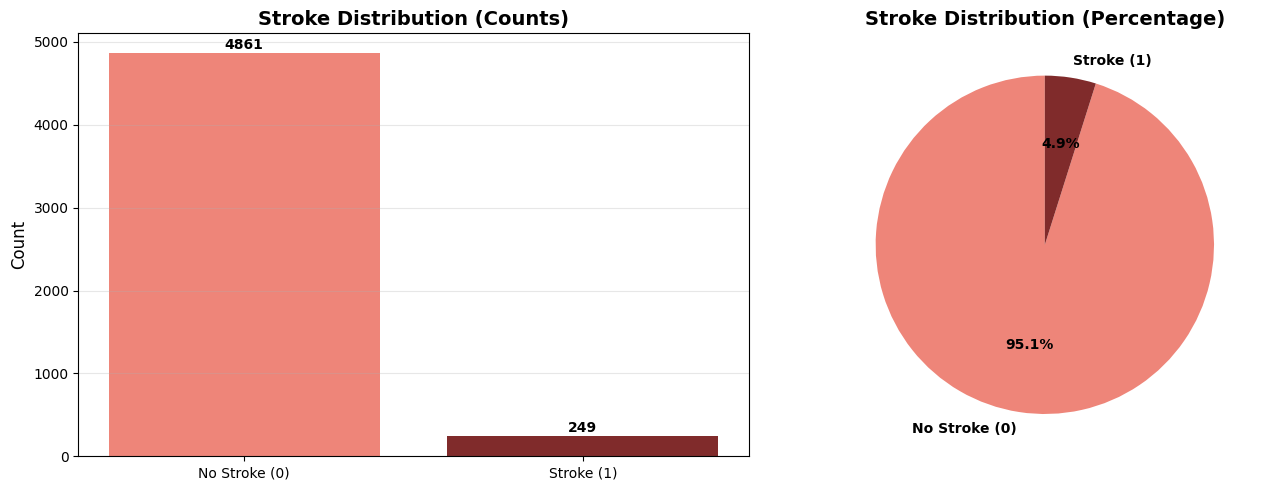

In [ ]:
# visualise target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# var plot
axes[0].bar(target_summary['Class'], target_summary['Count'], color=["#ee8579ff", '#802B2B'])
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Stroke Distribution (Counts)', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(target_summary['Count']):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# pie chart
colors = ["#ee8579ff", "#802B2B"]
axes[1].pie(
    target_summary['Percentage'],
    labels=target_summary['Class'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={
        'fontsize': 10,
        'fontweight': 'bold'
    }
)
axes[1].set_title('Stroke Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Insights**

- Class Imbalance: Severe imbalance with minority class (stroke=1) ~5% of data
- Imbalance Ratio: ~19:1 majority-to-minority ratio
- Baseline Accuracy: A naive "always No Stroke" classifier would achieve ~95% accuracy
- Sample Size: ~250 stroke cases - small but sufficient for baseline modelling

**Additional Insights and Assumptions**

- Achieving 70% recall target is challenging but feasible
- 5% stroke rate higher than population prevalence (2-3%), suggests clinical/high-risk sample
- Train-test split must be stratified to maintain class proportions

## 2.4 Missingness Analysis

We quantify the extent of missing data across all features.

In [ ]:
# calculate missing values
missing_summary = pd.DataFrame({
    'Feature': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
    'Data_Type': df.dtypes
}).sort_values('Missing_Percentage', ascending=False).reset_index(drop=True)

print("Missing Value Analysis")
print("="*60)
missing_summary

Missing Value Analysis


,Feature,Missing_Count,Missing_Percentage,Data_Type
0,bmi,201,3.93,float64
1,id,0,0.00,int64
2,age,0,0.00,float64
3,gender,0,0.00,object
4,hypertension,0,0.00,int64
5,heart_disease,0,0.00,int64
6,work_type,0,0.00,object
7,ever_married,0,0.00,object
8,Residence_type,0,0.00,object
9,avg_glucose_level,0,0.00,float64


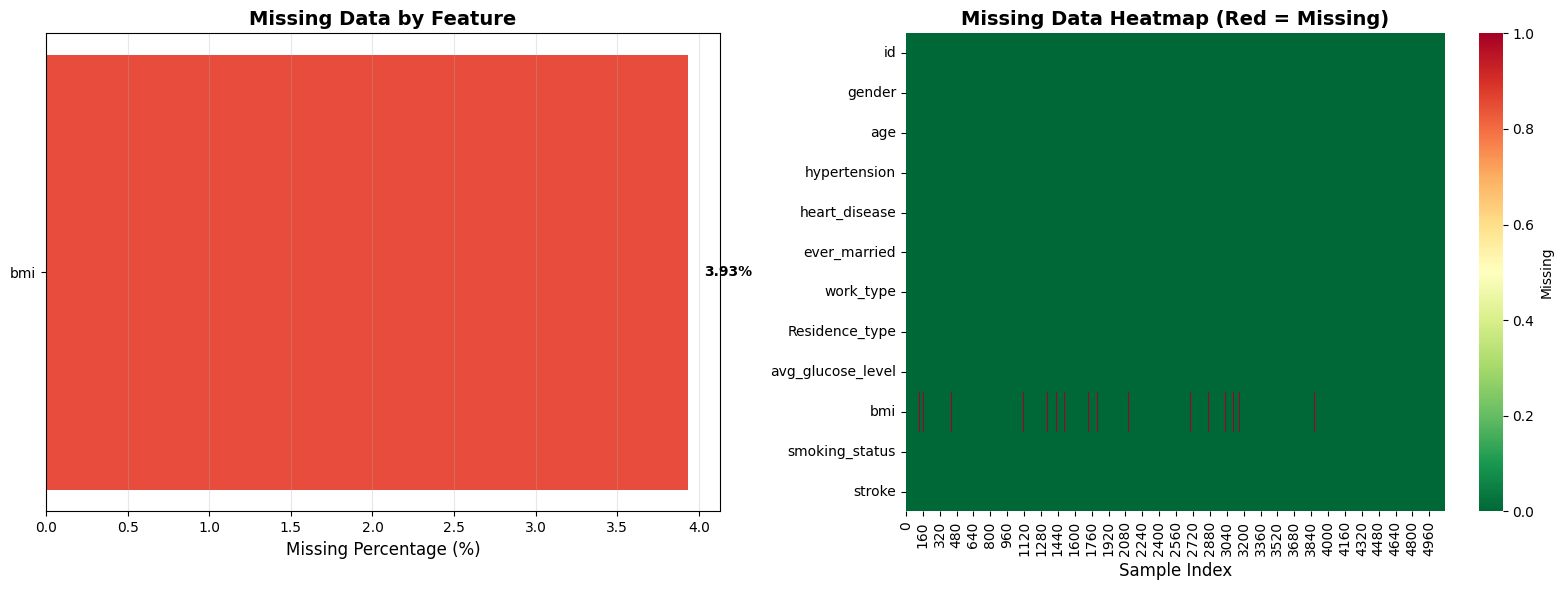


Overall missingness: 201/61320 (0.33%)


In [ ]:
# visualise missing data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# bar chart
features_with_missing = missing_summary[missing_summary['Missing_Count'] > 0]
if len(features_with_missing) > 0:
    axes[0].barh(features_with_missing['Feature'], features_with_missing['Missing_Percentage'],
                 color='#e74c3c')
    axes[0].set_xlabel('Missing Percentage (%)', fontsize=12)
    axes[0].set_title('Missing Data by Feature', fontsize=14, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    for i, v in enumerate(features_with_missing['Missing_Percentage']):
        axes[0].text(v + 0.1, i, f'{v:.2f}%', va='center', fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No missing values detected', ha='center', va='center', fontsize=14)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)

# heatmap
missing_matrix = df.isnull().astype(int)
sns.heatmap(missing_matrix.T, cmap='RdYlGn_r', cbar_kws={'label': 'Missing'},
           ax=axes[1], yticklabels=df.columns)
axes[1].set_title('Missing Data Heatmap (Red = Missing)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sample Index', fontsize=12)

plt.tight_layout()
plt.show()

# overall statistics
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
overall_missing_pct = (total_missing / total_cells) * 100
print(f"\nOverall missingness: {total_missing}/{total_cells} ({overall_missing_pct:.2f}%)")

**Insights**

- Primary Missing Feature: BMI is the only feature with missing values (~4%)
- Missing Count: 201 records missing BMI out of 5,110 total
- Data Completeness: All other features are 100% complete
- Pattern: Heatmap shows distribution of missing values

**Additional Insights and Assumptions**

- Manageable Missingness: 3.9% is below 5% threshold for simple imputation
- Assumption Validation: Need to verify if BMI missingness is MCAR or MAR
- Missing Pattern: Random distribution supports MCAR assumption
- Medical Context: BMI might be missing for patients without weight/height measurements

### 2.4.1 Impact of Missing Value on Target Variable

In [ ]:
# create indicator for missing BMI
df['bmi_missing'] = df['bmi'].isnull().astype(int)

# calculate stroke rate by BMI availability
bmi_missing_analysis = df.groupby('bmi_missing')['stroke'].agg(['count', 'sum', 'mean'])
bmi_missing_analysis.columns = ['Total_Records', 'Stroke_Cases', 'Stroke_Rate']
bmi_missing_analysis.index = ['BMI Available', 'BMI Missing']
bmi_missing_analysis['Stroke_Rate_Pct'] = bmi_missing_analysis['Stroke_Rate'] * 100

print("Stroke Rate by BMI Availability")
print("="*80)
print(bmi_missing_analysis)

# chi-square test
contingency_table = pd.crosstab(df['bmi_missing'], df['stroke'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-square test: χ² = {chi2:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("Result: Statistically significant relationship (p < 0.05)")
else:
    print("Result: No statistically significant relationship (p >= 0.05)")

Stroke Rate by BMI Availability
               Total_Records  Stroke_Cases  Stroke_Rate  Stroke_Rate_Pct
BMI Available           4909           209         0.04             4.26
BMI Missing              201            40         0.20            19.90

Chi-square test: χ² = 98.5888, p-value = 0.0000
Result: Statistically significant relationship (p < 0.05)


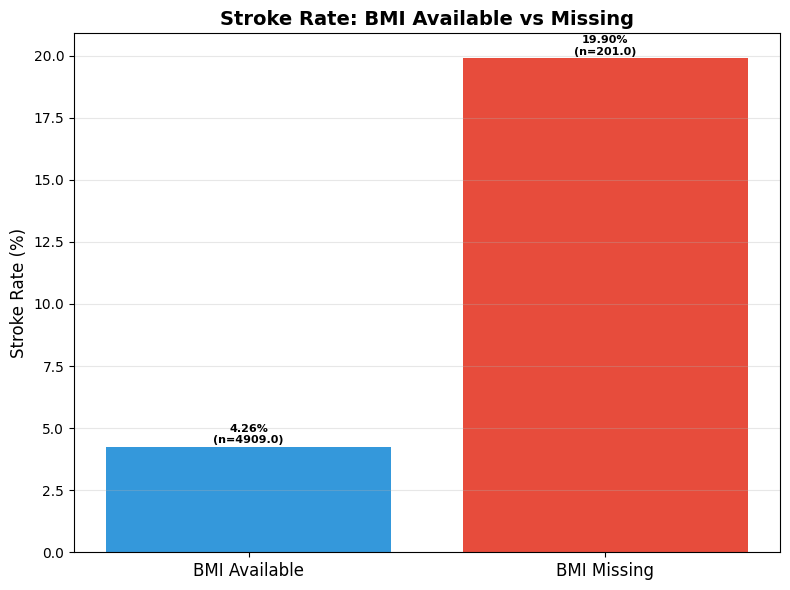

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
x_pos = np.arange(len(bmi_missing_analysis.index))
bars = ax.bar(x_pos, bmi_missing_analysis['Stroke_Rate_Pct'], color=['#3498db', '#e74c3c'])
ax.set_xticks(x_pos)
ax.set_xticklabels(bmi_missing_analysis.index, fontsize=12)
ax.set_ylabel('Stroke Rate (%)', fontsize=12)
ax.set_title('Stroke Rate: BMI Available vs Missing', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, (bar, value) in enumerate(zip(bars, bmi_missing_analysis['Stroke_Rate_Pct'])):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., height + 0.05,
        f'{value:.2f}%\n(n={bmi_missing_analysis.iloc[i]["Total_Records"]})',
        ha='center', va='bottom', fontweight='bold', fontsize=8
    )

plt.tight_layout()
plt.show()

**Insights**

- Stroke Rate Comparison: This reveals difference in stroke rate between complete/missing BMI groups
- Statistical Significance: Chi-square test determines if difference is statistically significant
- Sample Sizes: Both groups have adequate representation
- Direction of Effect: Higher stroke rate in missing BMI group suggests non-random missingness

**Additional Insights and Assumptions**

- Missingness Mechanism: If p < 0.05, BMI missingness relates to outcome (MNAR or MAR)
- Selection Bias: Higher stroke rate in missing group indicates sicker patients had incomplete measurements
- Imputation Validity: If missingness correlates with outcome, simple mean imputation may introduce bias
- Alternative Explanation: Missing BMI could proxy for emergency admissions without complete workup

## 2.5 Feature Distributions

Visualising feature distributions helps us understand the data generating process and identify potential issues such as skewness, multimodality, or unexpected patterns. For numerical features, we use histograms, box plots, and density plots, while for categorical features we examine frequency distributions.

From a clinical perspective, the age distribution should reflect the target screening population. Glucose levels can be categorised into normal (below 100 mg/dL), pre-diabetic (100–125 mg/dL), and diabetic (126 mg/dL and above). BMI categories follow WHO standards: underweight (below 18.5), normal (18.5–24.9), overweight (25–29.9), and obese (30 and above).

### 2.5.1 Distribution of Numerical Features


#### 2.5.1.a Age Distrubtion

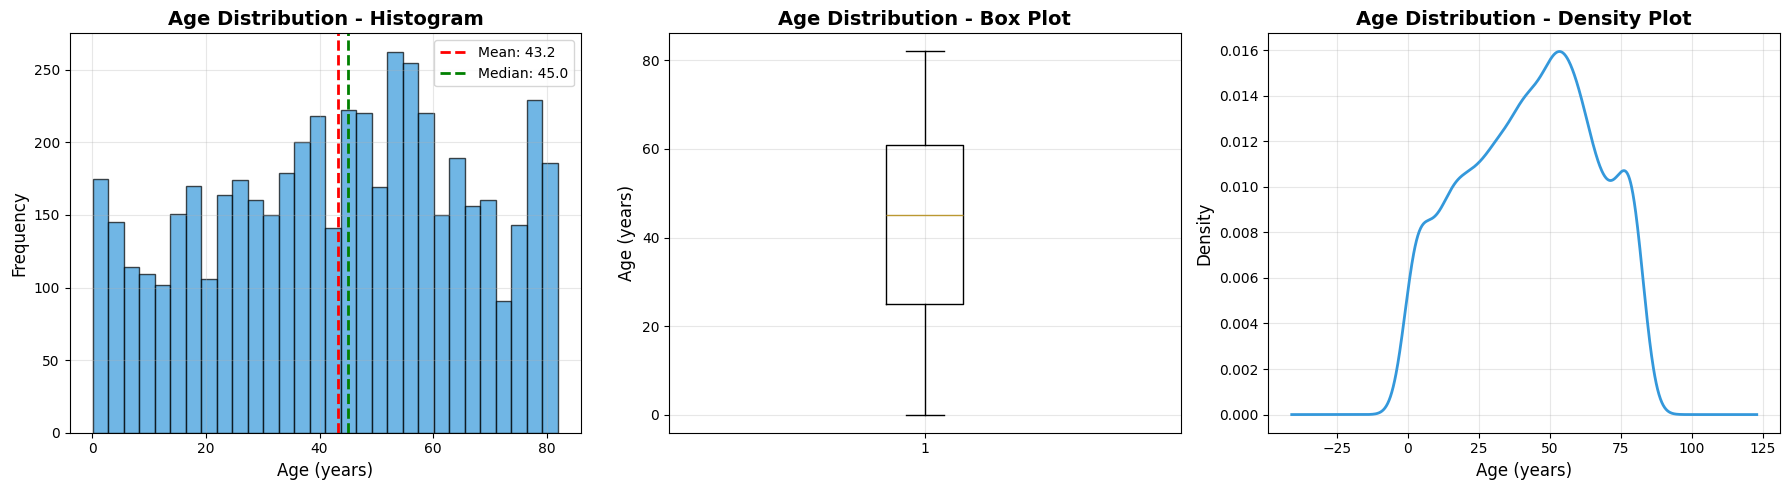

In [ ]:
# age distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# histogram
axes[0].hist(df['age'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {df["age"].mean():.1f}')
axes[0].axvline(df['age'].median(), color='green', linestyle='--', linewidth=2,
               label=f'Median: {df["age"].median():.1f}')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Age Distribution - Histogram', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# box plot
axes[1].boxplot(df['age'], vert=True)
axes[1].set_ylabel('Age (years)', fontsize=12)
axes[1].set_title('Age Distribution - Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

# density plot
df['age'].plot(kind='density', ax=axes[2], color='#3498db', linewidth=2)
axes[2].set_xlabel('Age (years)', fontsize=12)
axes[2].set_ylabel('Density', fontsize=12)
axes[2].set_title('Age Distribution - Density Plot', fontsize=14, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("Age Statistics")
print("="*30)
print(f"Mean: {df['age'].mean():.2f} years")
print(f"Median: {df['age'].median():.2f} years")
print(f"Std Dev: {df['age'].std():.2f} years")
print(f"Range: {df['age'].min():.2f} - {df['age'].max():.2f} years")
print(f"Skewness: {df['age'].skew():.2f}")

Age Statistics
Mean: 43.23 years
Median: 45.00 years
Std Dev: 22.61 years
Range: 0.08 - 82.00 years
Skewness: -0.14


**Insights**

- Distribution Shape: Age shows the overall pattern and skew
- Central Tendency: Mean and median indicate typical age
- Spread: Standard deviation reveals age variability
- Outliers: Box plot identifies extreme age values
- Skewness: Right-tailed distribution with more younger patients

**Additional Insights and Assumptions**

- Clinical Relevance: Age range should align with stroke risk populations (45+ higher risk)
- Data Quality: Minimum age ~0.08 years requires investigation (paediatric stroke or error)
- Maximum Age: Medically plausible if <120 years
- Distribution Type: Skewed distribution expected (stroke risk increases with age)
- Modelling: Likely most important predictor given strong medical association
- Population: Wide age range good for model generalisability

#### 2.5.1.b Average Glucose Level Distribution

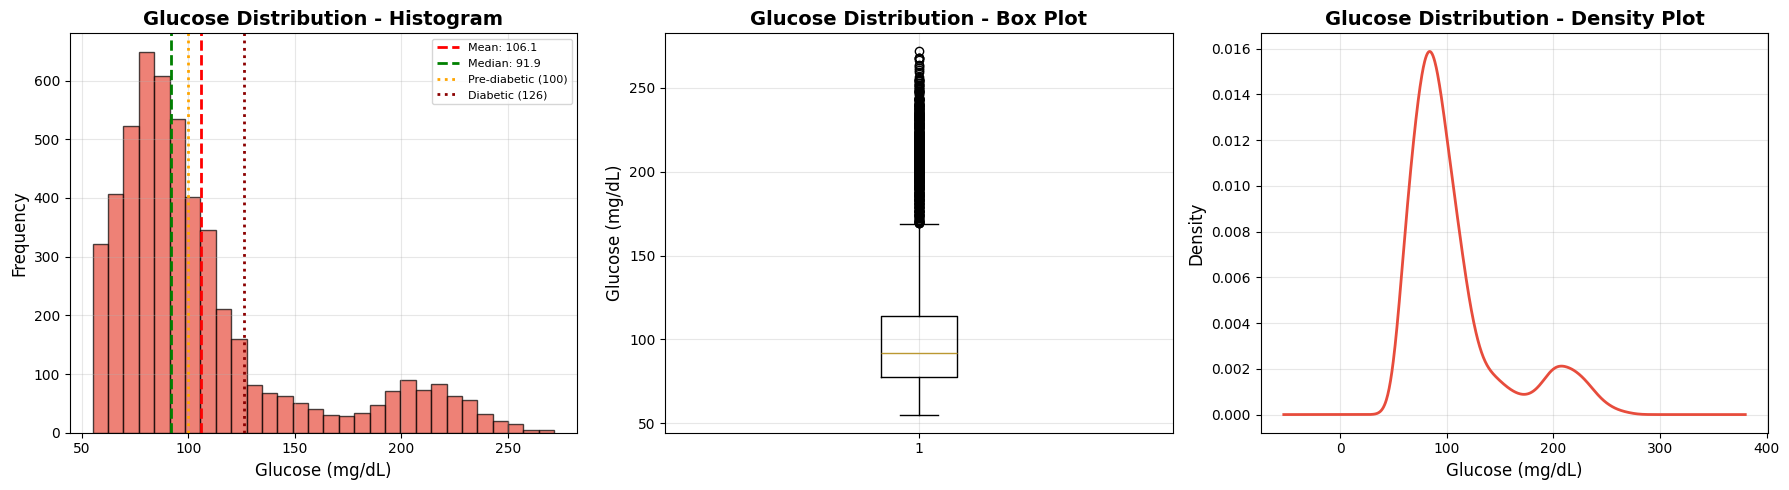

In [ ]:
# glucose distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# histogram
axes[0].hist(df['avg_glucose_level'], bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0].axvline(df['avg_glucose_level'].mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {df["avg_glucose_level"].mean():.1f}')
axes[0].axvline(df['avg_glucose_level'].median(), color='green', linestyle='--', linewidth=2,
               label=f'Median: {df["avg_glucose_level"].median():.1f}')
axes[0].axvline(100, color='orange', linestyle=':', linewidth=2, label='Pre-diabetic (100)')
axes[0].axvline(126, color='darkred', linestyle=':', linewidth=2, label='Diabetic (126)')
axes[0].set_xlabel('Glucose (mg/dL)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Glucose Distribution - Histogram', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# box plot
axes[1].boxplot(df['avg_glucose_level'], vert=True)
axes[1].set_ylabel('Glucose (mg/dL)', fontsize=12)
axes[1].set_title('Glucose Distribution - Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

# density plot
df['avg_glucose_level'].plot(kind='density', ax=axes[2], color='#e74c3c', linewidth=2)
axes[2].set_xlabel('Glucose (mg/dL)', fontsize=12)
axes[2].set_ylabel('Density', fontsize=12)
axes[2].set_title('Glucose Distribution - Density Plot', fontsize=14, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\nGlucose Statistics")
print("="*30)
print(f"Mean: {df['avg_glucose_level'].mean():.2f} mg/dL")
print(f"Median: {df['avg_glucose_level'].median():.2f} mg/dL")
print(f"Std Dev: {df['avg_glucose_level'].std():.2f} mg/dL")
print(f"Range: {df['avg_glucose_level'].min():.2f} - {df['avg_glucose_level'].max():.2f} mg/dL")

print("\nClinical Categories")
print("="*30)
print(f"Normal (<100): {(df['avg_glucose_level'] < 100).sum()} ({(df['avg_glucose_level'] < 100).sum()/len(df)*100:.1f}%)")
print(f"Pre-diabetic (100-125): {((df['avg_glucose_level'] >= 100) & (df['avg_glucose_level'] < 126)).sum()} ({((df['avg_glucose_level'] >= 100) & (df['avg_glucose_level'] < 126)).sum()/len(df)*100:.1f}%)")
print(f"Diabetic (>=126): {(df['avg_glucose_level'] >= 126).sum()} ({(df['avg_glucose_level'] >= 126).sum()/len(df)*100:.1f}%)")


Glucose Statistics
Mean: 106.15 mg/dL
Median: 91.88 mg/dL
Std Dev: 45.28 mg/dL
Range: 55.12 - 271.74 mg/dL

Clinical Categories
Normal (<100): 3131 (61.3%)
Pre-diabetic (100-125): 998 (19.5%)
Diabetic (>=126): 981 (19.2%)


**Insights**

- Distribution: Right-skewed with majority in normal-to-pre-diabetic range
- Clinical Thresholds: Distribution relative to diagnostic cutoffs shows population metabolic health
- Outliers: Upper tail identifies patients with very high glucose (diabetic emergencies)
- Variability: Standard deviation indicates population heterogeneity

**Additional Insights and Assumptions**

- Clinical Plausibility: Range 55-271 mg/dL is medically plausible
- Diabetes Prevalence: Proportion ≥126 mg/dL indicates metabolic disease burden
- Stroke Risk: Elevated glucose is known risk factor
- Measurement: Average glucose suggests repeated or fasting measurements
- Right Skew: Expected due to diabetic subpopulation
- Feature Quality: Complete data (no missing) is advantageous

#### 2.5.1.c BMI Distribution

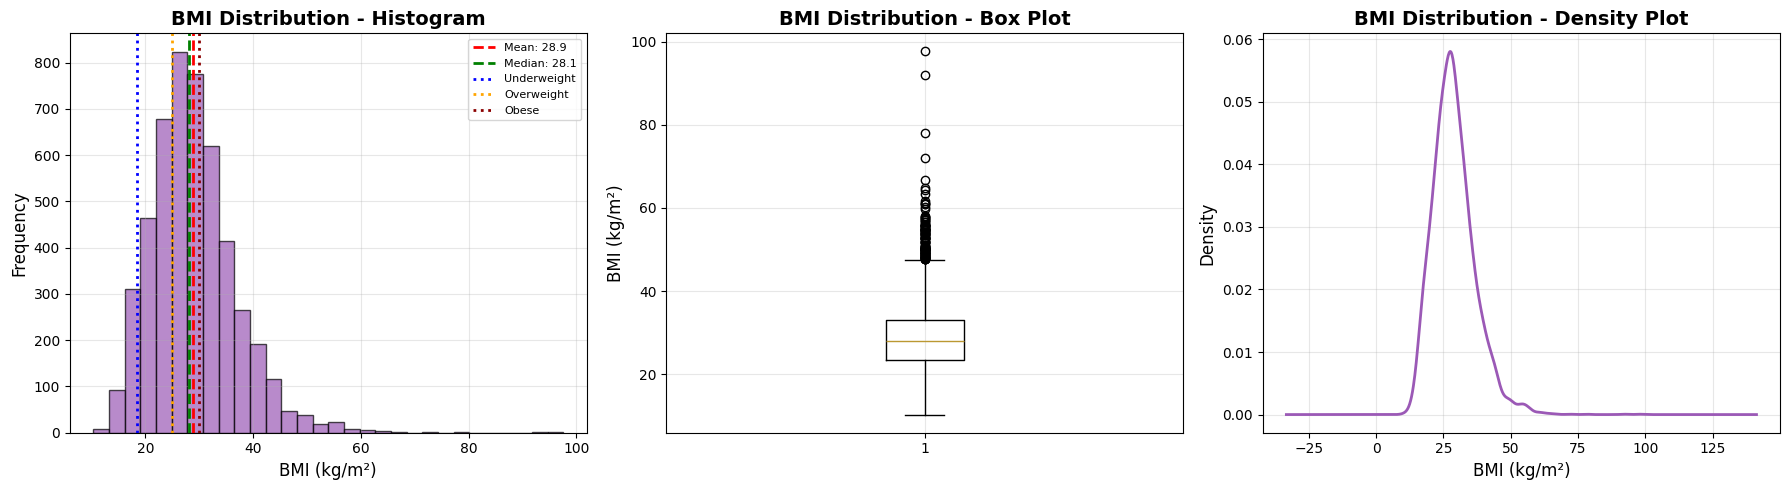

In [ ]:
# BMI distribution (excluding missing)
bmi_complete = df['bmi'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# histogram
axes[0].hist(bmi_complete, bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[0].axvline(bmi_complete.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {bmi_complete.mean():.1f}')
axes[0].axvline(bmi_complete.median(), color='green', linestyle='--', linewidth=2,
               label=f'Median: {bmi_complete.median():.1f}')
axes[0].axvline(18.5, color='blue', linestyle=':', linewidth=2, label='Underweight')
axes[0].axvline(25, color='orange', linestyle=':', linewidth=2, label='Overweight')
axes[0].axvline(30, color='darkred', linestyle=':', linewidth=2, label='Obese')
axes[0].set_xlabel('BMI (kg/m²)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('BMI Distribution - Histogram', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# box plot
axes[1].boxplot(bmi_complete, vert=True)
axes[1].set_ylabel('BMI (kg/m²)', fontsize=12)
axes[1].set_title('BMI Distribution - Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

# density plot
bmi_complete.plot(kind='density', ax=axes[2], color='#9b59b6', linewidth=2)
axes[2].set_xlabel('BMI (kg/m²)', fontsize=12)
axes[2].set_ylabel('Density', fontsize=12)
axes[2].set_title('BMI Distribution - Density Plot', fontsize=14, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\nBMI Statistics (excluding missing)")
print("="*30)
print(f"Count: {len(bmi_complete)} (missing: {df['bmi'].isnull().sum()})")
print(f"Mean: {bmi_complete.mean():.2f} kg/m²")
print(f"Median: {bmi_complete.median():.2f} kg/m²")
print(f"Std Dev: {bmi_complete.std():.2f} kg/m²")
print(f"Range: {bmi_complete.min():.2f} - {bmi_complete.max():.2f} kg/m²")

print("\nBMI Categories (WHO)")
print("="*30)
print(f"Underweight (<18.5): {(bmi_complete < 18.5).sum()} ({(bmi_complete < 18.5).sum()/len(bmi_complete)*100:.1f}%)")
print(f"Normal (18.5-24.9): {((bmi_complete >= 18.5) & (bmi_complete < 25)).sum()} ({((bmi_complete >= 18.5) & (bmi_complete < 25)).sum()/len(bmi_complete)*100:.1f}%)")
print(f"Overweight (25-29.9): {((bmi_complete >= 25) & (bmi_complete < 30)).sum()} ({((bmi_complete >= 25) & (bmi_complete < 30)).sum()/len(bmi_complete)*100:.1f}%)")
print(f"Obese (>=30): {(bmi_complete >= 30).sum()} ({(bmi_complete >= 30).sum()/len(bmi_complete)*100:.1f}%)")


BMI Statistics (excluding missing)
Count: 4909 (missing: 201)
Mean: 28.89 kg/m²
Median: 28.10 kg/m²
Std Dev: 7.85 kg/m²
Range: 10.30 - 97.60 kg/m²

BMI Categories (WHO)
Underweight (<18.5): 337 (6.9%)
Normal (18.5-24.9): 1243 (25.3%)
Overweight (25-29.9): 1409 (28.7%)
Obese (>=30): 1920 (39.1%)


**Insights**

- Distribution: Overall BMI pattern reveals population weight status
- Clinical Categories: Distribution across WHO BMI categories shows obesity prevalence
- Outliers: Extreme values require investigation
- Missing Impact: Analysis on ~96% of dataset

**Additional Insights and Assumptions**

- Clinical Plausibility: BMI should be 15-60 kg/m²; outside suggests errors
- Obesity Prevalence: Proportion BMI ≥30 indicates metabolic risk
- Stroke Risk: Both obesity (>30) and underweight (<18.5) increase stroke risk
- Data Quality: Extreme values (<15 or >60) warrant investigation
- Measurement: BMI = weight/height², so errors compound
- Missing Data: 201 records need imputation strategy
- Feature Utility: Standard cardiovascular risk factor

#### 2.5.1.d Distribution Normality Test

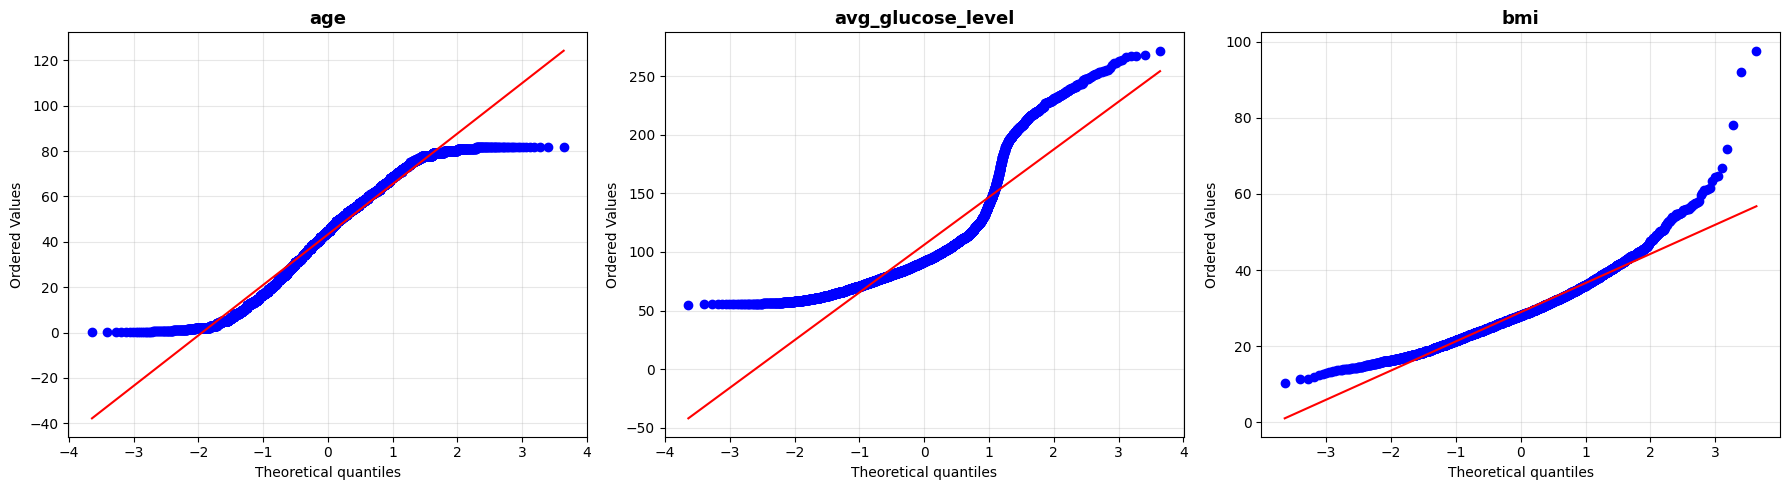

In [ ]:
# Q-Q plots for numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(['age', 'avg_glucose_level', 'bmi']):
    data = df[feature].dropna()
    stats.probplot(data, dist="norm", plot=axes[idx])
    axes[idx].set_title(f'{feature}', fontsize=13, fontweight='bold')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("Normality Assessment:")
print("="*60)
for feature in ['age', 'avg_glucose_level', 'bmi']:
    data = df[feature].dropna()
    skew = data.skew()
    kurt = data.kurtosis()

    print(f"{feature}:")
    print(f"  Skewness: {skew:.3f}")
    print(f"  Kurtosis: {kurt:.3f}")

    if abs(skew) < 0.5:
        print(f"  Distribution: Approximately symmetric")
    elif skew > 0:
        print(f"  Distribution: Right-skewed (positive skew)")
    else:
        print(f"  Distribution: Left-skewed (negative skew)")
    print()

Normality Assessment:
age:
  Skewness: -0.137
  Kurtosis: -0.991
  Distribution: Approximately symmetric

avg_glucose_level:
  Skewness: 1.572
  Kurtosis: 1.680
  Distribution: Right-skewed (positive skew)

bmi:
  Skewness: 1.055
  Kurtosis: 3.363
  Distribution: Right-skewed (positive skew)



**Insights**

- Age: Approximately symmetric distribution (skewness = -0.137), closest to normality among the three features
- Glucose: Right-skewed; typical for medical populations with diabetic subgroup
- BMI: Moderately right-skewed distribution (skewness = 1.055)
- Q-Q Patterns: Deviations from reference line indicate non-normality in glucose and BMI; age shows approximate normality

**Additional Insights and Assumptions**

- Normality Violations: Expected in medical data (not concerning)
- Model Implications: Some classical models assume normality (e.g., linear regression, LDA)
- Transformation Consideration: Log or Box-Cox transformations could help (but not in Stage 1)
- Baseline Models: Logistic regression and random forest handle non-normality well
- Distribution Types: Age approximately normal, glucose log-normal, BMI positively skewed
- Feature Engineering: Later stages could benefit from distribution-aware transformations

### 2.5.2 Distribution of Categorical Features

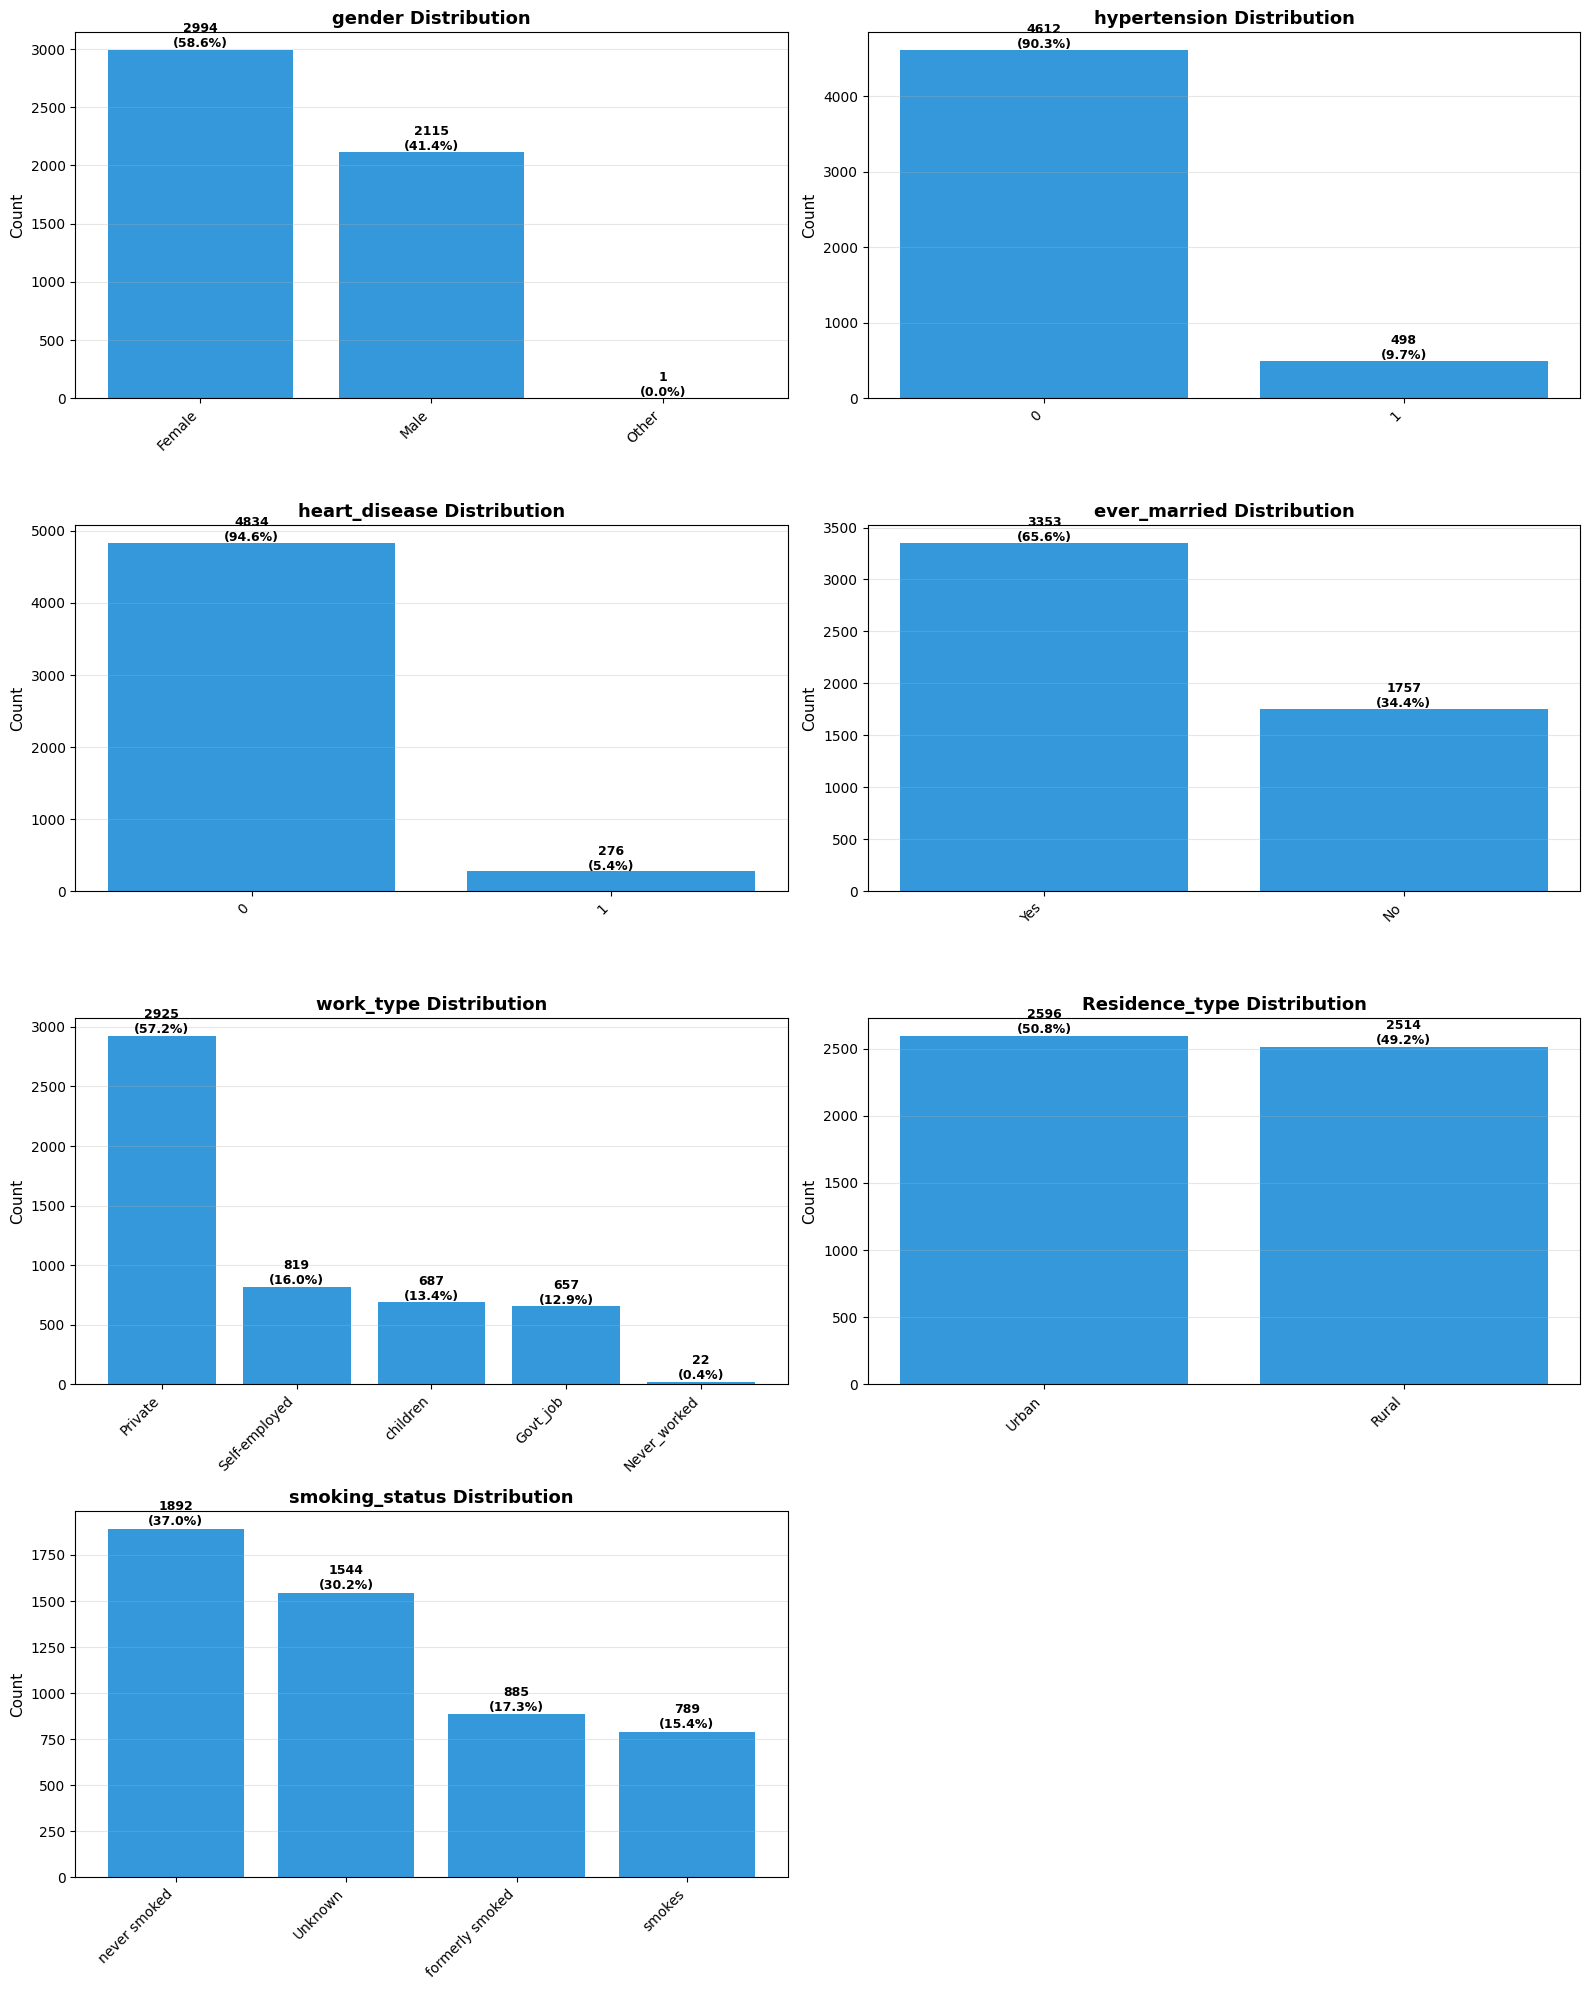

In [ ]:
# create visualisations for all categorical features
categorical_features = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                       'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    counts = df[feature].value_counts()
    axes[idx].bar(range(len(counts)), counts.values, color='#3498db')
    axes[idx].set_xticks(range(len(counts)))
    axes[idx].set_xticklabels(counts.index, rotation=45, ha='right')
    axes[idx].set_ylabel('Count', fontsize=11)
    axes[idx].set_title(f'{feature} Distribution', fontsize=13, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

    for i, v in enumerate(counts.values):
        axes[idx].text(i, v + 20, f'{v}\n({v/len(df)*100:.1f}%)',
                      ha='center', fontsize=9, fontweight='bold')

# remove extra subplot
axes[7].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print("Categorical Features Summary:")
print("="*30)
for feature in categorical_features:
    print(f"\n{feature}:")
    print(df[feature].value_counts())

Categorical Features Summary:

gender:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

hypertension:
hypertension
0    4612
1     498
Name: count, dtype: int64

heart_disease:
heart_disease
0    4834
1     276
Name: count, dtype: int64

ever_married:
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

work_type:
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Residence_type:
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


**Insights**

- Gender: Female-skewed distribution
- Hypertension/Heart Disease: Binary indicators showing condition prevalence
- Ever Married: Marital status history
- Work Type: Multiple employment categories
- Residence: Urban/rural distribution
- Smoking Status: Includes "Unknown" category (~30%)

**Additional Insights and Assumptions**

- "Unknown" smoking status indicates data quality issue
- Binary medical conditions straightforward for encoding
- Work type shows life stage diversity (children, employed, never worked)
- Nominal categories require one-hot encoding
- Rare categories may cause stratification issues
- Marital status likely correlates with age (potential redundancy)

## 2.6 Bivariate Analysis

### 2.6.1 Feature-Target Relationships

To assess the predictive potential of each feature, we examine their relationships with the target variable. This bivariate analysis helps us understand which features are likely to be informative for the model and validates our assumptions from the Business Understanding phase about known stroke risk factors.

For numerical features, we compare distributions between stroke and non-stroke groups using statistical tests. For categorical features, we calculate stroke rates across categories and test for significant associations. We expect features such as age, hypertension, and heart disease to show strong relationships, aligning with established clinical knowledge.

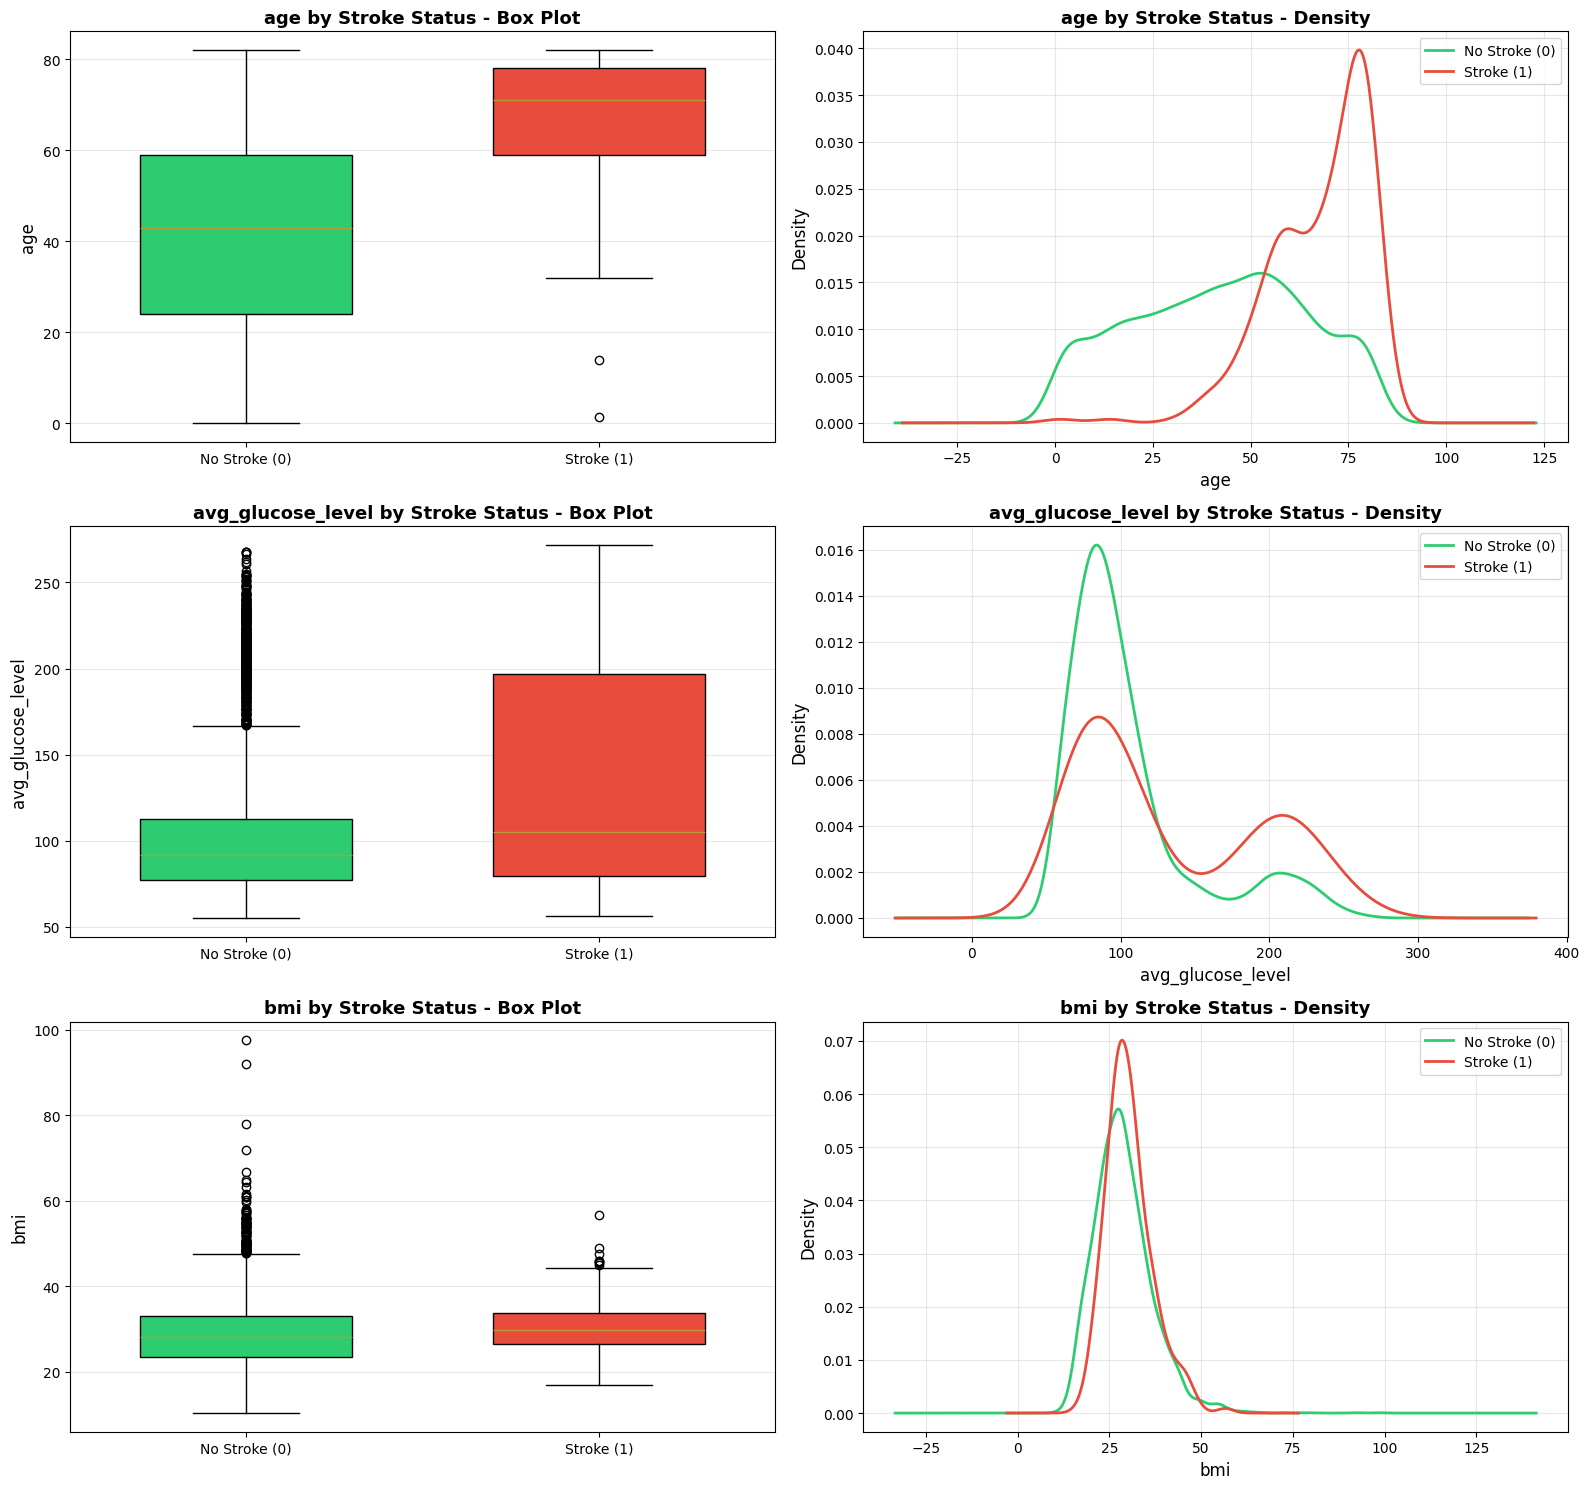

In [ ]:
# numerical vs target analysis
numerical_features = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(3, 2, figsize=(16, 15))

for idx, feature in enumerate(numerical_features):
    # filter data
    if feature == 'bmi':
        data_complete = df[df[feature].notna()]
    else:
        data_complete = df

    # box plots
    stroke_groups = data_complete.groupby('stroke')[feature]
    box_data = [stroke_groups.get_group(0), stroke_groups.get_group(1)]
    bp = axes[idx, 0].boxplot(box_data, positions=[0, 1],
                              labels=['No Stroke (0)', 'Stroke (1)'],
                              patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
        patch.set_facecolor(color)
    axes[idx, 0].set_ylabel(f'{feature}', fontsize=12)
    axes[idx, 0].set_title(f'{feature} by Stroke Status - Box Plot',
                          fontsize=13, fontweight='bold')
    axes[idx, 0].grid(axis='y', alpha=0.3)

    # density plots
    data_complete[data_complete['stroke']==0][feature].plot(
        kind='density', ax=axes[idx, 1], label='No Stroke (0)',
        color='#2ecc71', linewidth=2)
    data_complete[data_complete['stroke']==1][feature].plot(
        kind='density', ax=axes[idx, 1], label='Stroke (1)',
        color='#e74c3c', linewidth=2)
    axes[idx, 1].set_xlabel(f'{feature}', fontsize=12)
    axes[idx, 1].set_ylabel('Density', fontsize=12)
    axes[idx, 1].set_title(f'{feature} by Stroke Status - Density',
                          fontsize=13, fontweight='bold')
    axes[idx, 1].legend(fontsize=10)
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("Statistical Comparison (T-tests):")
print("="*40)
for feature in numerical_features:
    if feature == 'bmi':
        data_complete = df[df[feature].notna()]
    else:
        data_complete = df

    group0 = data_complete[data_complete['stroke']==0][feature]
    group1 = data_complete[data_complete['stroke']==1][feature]

    t_stat, p_value = ttest_ind(group1, group0)

    print(f"{feature}:")
    print(f"  No Stroke: Mean={group0.mean():.2f}, SD={group0.std():.2f}")
    print(f"  Stroke:    Mean={group1.mean():.2f}, SD={group1.std():.2f}")
    print(f"  Difference: {group1.mean()-group0.mean():.2f}")
    print(f"  T-test: t={t_stat:.4f}, p={p_value:.4e}")
    print(f"  Significant: {'Yes (p<0.05)' if p_value < 0.05 else 'No (p>=0.05)'}\n")

Statistical Comparison (T-tests):
age:
  No Stroke: Mean=41.97, SD=22.29
  Stroke:    Mean=67.73, SD=12.73
  Difference: 25.76
  T-test: t=18.0808, p=7.0308e-71
  Significant: Yes (p<0.05)

avg_glucose_level:
  No Stroke: Mean=104.80, SD=43.85
  Stroke:    Mean=132.54, SD=61.92
  Difference: 27.75
  T-test: t=9.5134, p=2.7678e-21
  Significant: Yes (p<0.05)

bmi:
  No Stroke: Mean=28.82, SD=7.91
  Stroke:    Mean=30.47, SD=6.33
  Difference: 1.65
  T-test: t=2.9709, p=2.9833e-03
  Significant: Yes (p<0.05)



**Insights**

- Age: Strong separation between groups; stroke patients significantly older
- Glucose: Moderate elevation in stroke group; diabetes connection evident
- BMI: Difference present but weaker than age/glucose
- All features show statistically significant differences (p < 0.05)
- Age shows least distribution overlap and is the strongest discriminator

**Additional Insights and Assumptions**

- Medical Validation: Results align with known stroke risk factors
- Age Dominance: Age likely most important predictor
- Model Feasibility: Strong feature-target relationships support 70% recall target
- Feature Utility: All numerical features contribute unique information
- Non-linear Effects: Linear comparisons may miss threshold effects

### 2.6.2 Categorical Features vs Target Variable

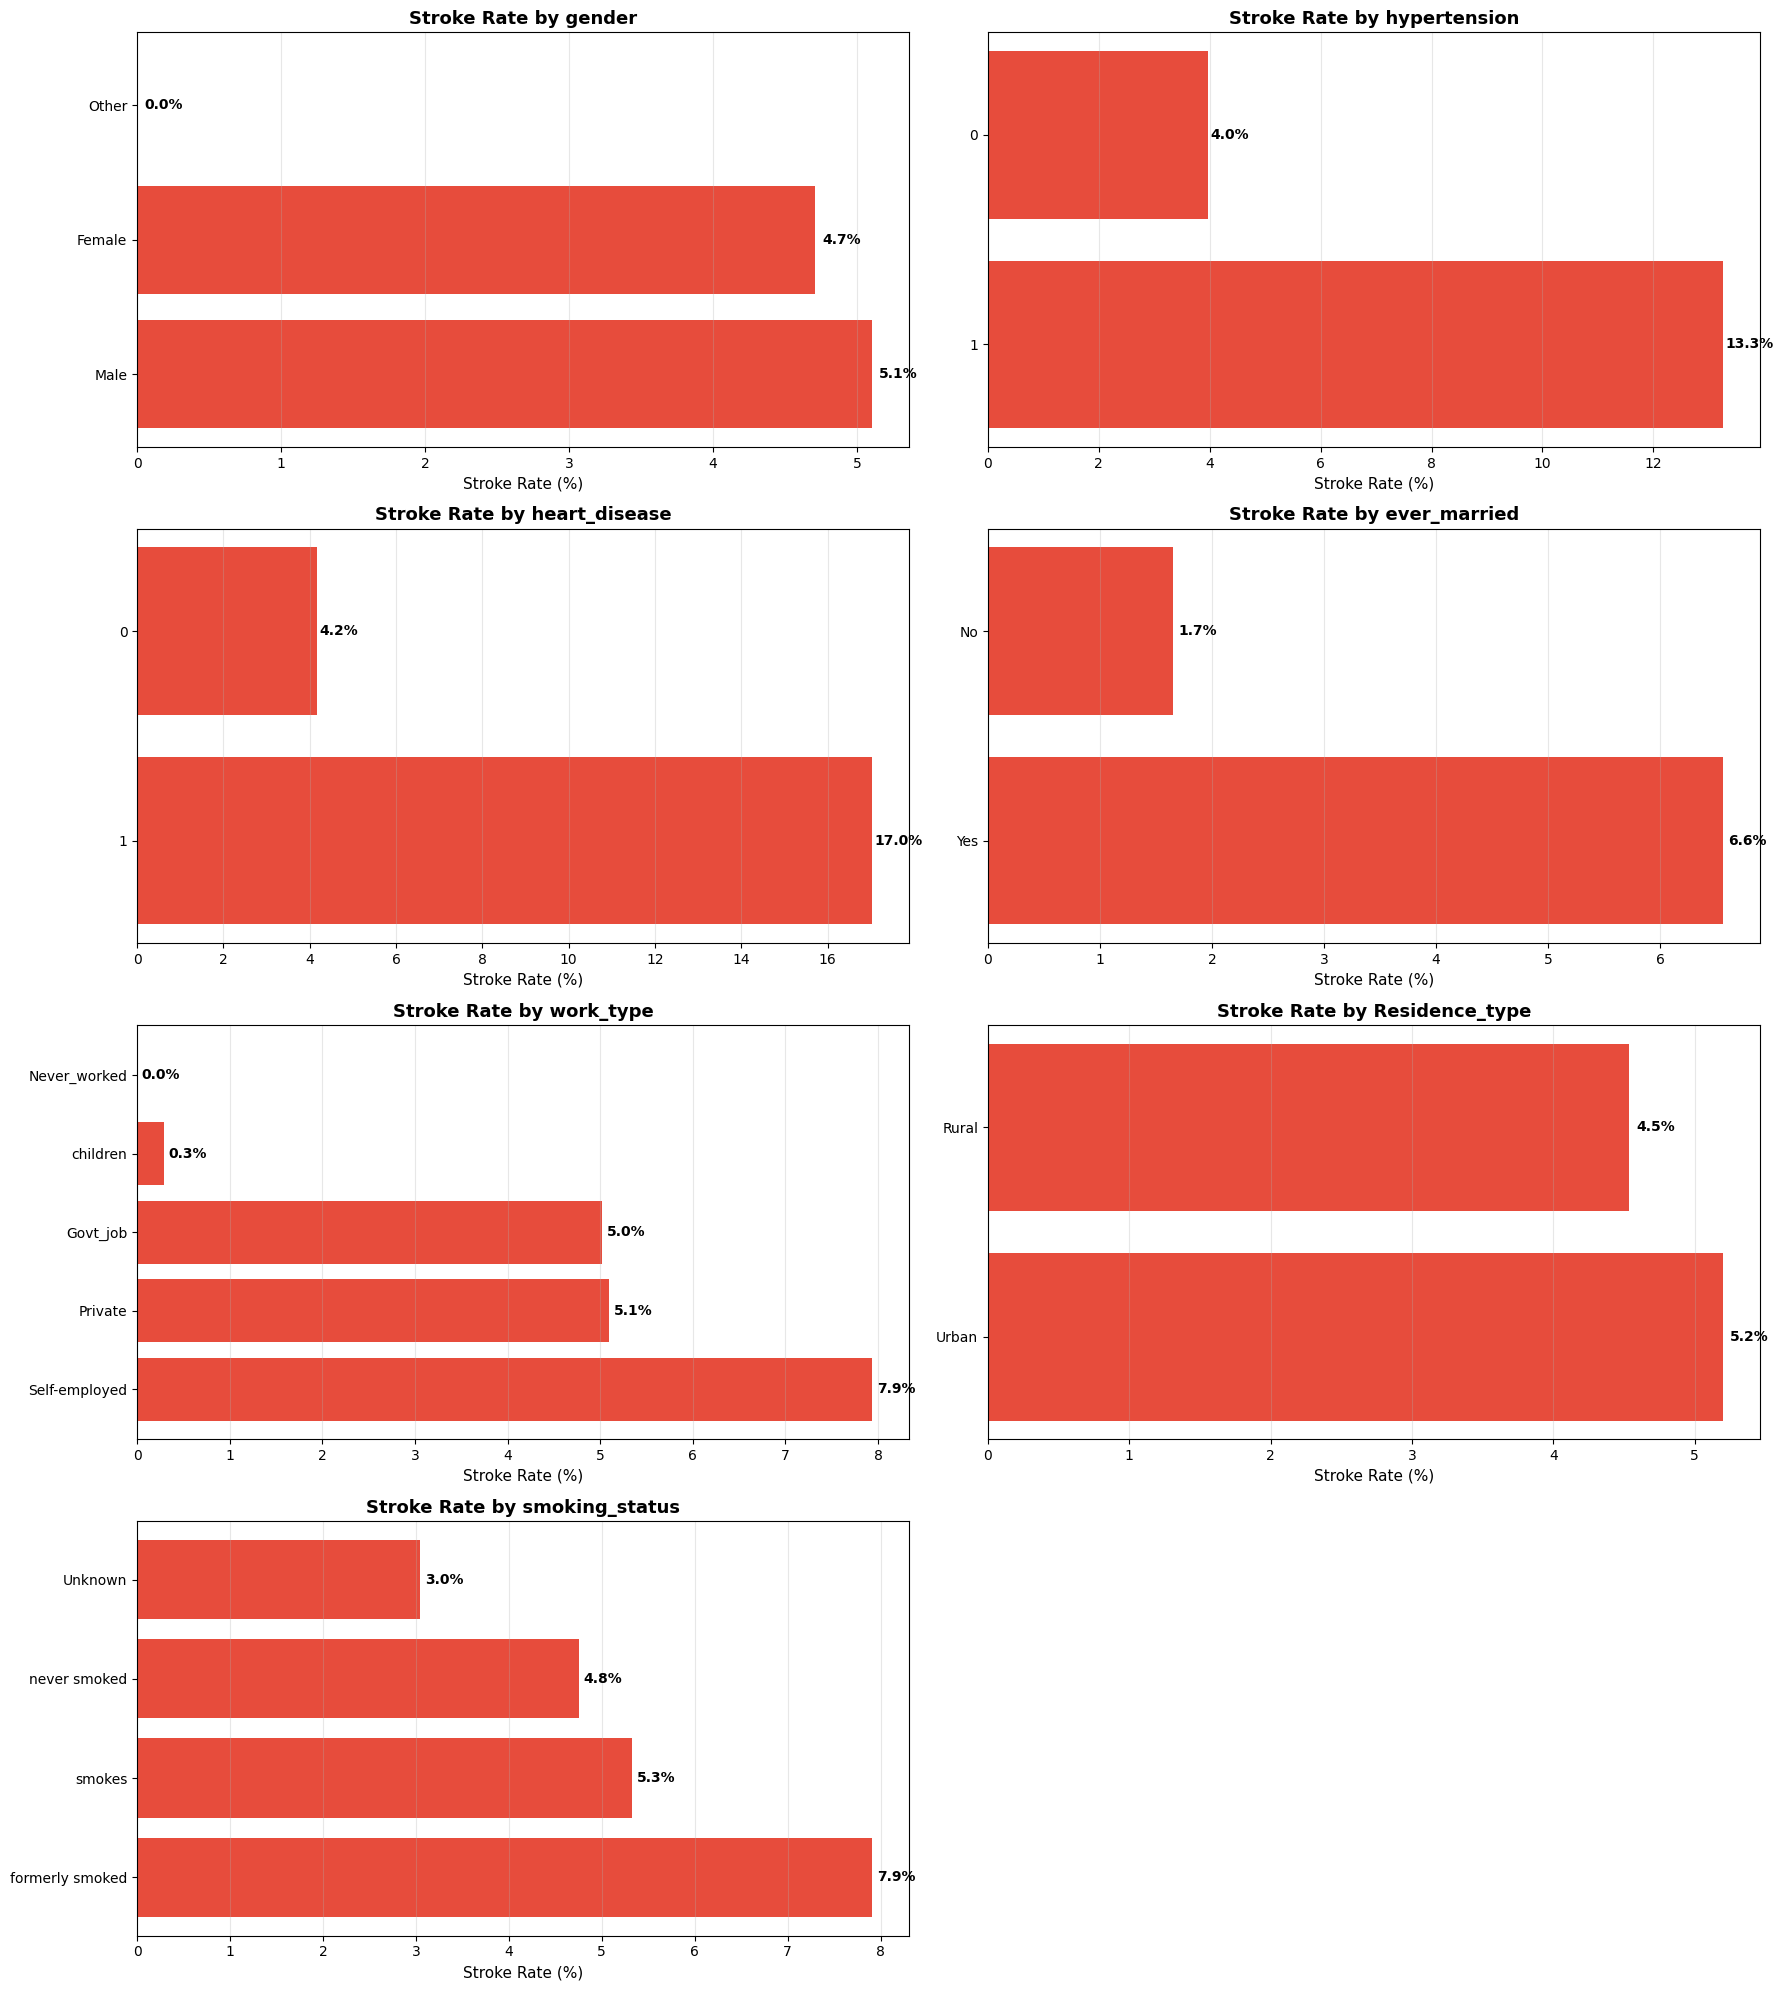

In [ ]:
# categorical vs target analysis
categorical_features = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                       'work_type', 'Residence_type', 'smoking_status']

# calculate stroke rates
stroke_rates = {}
for feature in categorical_features:
    rates = df.groupby(feature)['stroke'].agg(['sum', 'count', 'mean'])
    rates['percentage'] = rates['mean'] * 100
    stroke_rates[feature] = rates

# visualise
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    data = stroke_rates[feature].sort_values('percentage', ascending=False)
    axes[idx].barh(range(len(data)), data['percentage'].values, color='#e74c3c')
    axes[idx].set_yticks(range(len(data)))
    axes[idx].set_yticklabels(data.index)
    axes[idx].set_xlabel('Stroke Rate (%)', fontsize=11)
    axes[idx].set_title(f'Stroke Rate by {feature}', fontsize=13, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)

    for i, v in enumerate(data['percentage'].values):
        axes[idx].text(v + 0.05, i, f'{v:.1f}%', va='center', fontweight='bold')

axes[7].axis('off')
plt.tight_layout()
plt.show()

### 2.6.3 Statistical Testing

Beyond visual inspection, we apply formal statistical tests to quantify the strength of feature-target relationships. This provides objective evidence for feature relevance and helps prioritise which features warrant closer attention.

The chi-square test is applied to categorical features to determine whether the distribution of stroke cases differs significantly across categories. For numerical features, the independent t-test assesses whether mean values differ significantly between stroke and non-stroke groups. We use a significance level of α = 0.05, which is the standard threshold for medical research.

In [ ]:
# chi-square tests
print("Chi-Square Tests:")
print("="*30)
for feature in categorical_features:
    contingency = pd.crosstab(df[feature], df['stroke'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    # cramer's V
    n = contingency.sum().sum()
    min_dim = min(contingency.shape[0]-1, contingency.shape[1]-1)
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    print(f"{feature}:")
    print(f"  χ²={chi2:.4f}, p={p_value:.4e}")
    print(f"  Cramér's V={cramers_v:.4f}")
    print(f"  Significant: {'Yes (p<0.05)' if p_value < 0.05 else 'No (p>=0.05)'}\n")

Chi-Square Tests:
gender:
  χ²=0.4726, p=7.8955e-01
  Cramér's V=0.0096
  Significant: No (p>=0.05)

hypertension:
  χ²=81.6054, p=1.6616e-19
  Cramér's V=0.1264
  Significant: Yes (p<0.05)

heart_disease:
  χ²=90.2596, p=2.0888e-21
  Cramér's V=0.1329
  Significant: Yes (p<0.05)

ever_married:
  χ²=58.9239, p=1.6389e-14
  Cramér's V=0.1074
  Significant: Yes (p<0.05)

work_type:
  χ²=49.1635, p=5.3977e-10
  Cramér's V=0.0981
  Significant: Yes (p<0.05)

Residence_type:
  χ²=1.0816, p=2.9833e-01
  Cramér's V=0.0145
  Significant: No (p>=0.05)

smoking_status:
  χ²=29.1473, p=2.0854e-06
  Cramér's V=0.0755
  Significant: Yes (p<0.05)



**Insights**

- Hypertension: Strong association with stroke (higher rate in hypertensive patients)
- Heart Disease: Significant association with stroke
- Age-Related Features: Ever married, work type show associations (likely mediated by age)
- Gender: Moderate difference in stroke rates
- Smoking: Current/former smokers show elevated risk
- Residence: Minimal difference urban vs rural

**Additional Insights and Assumptions**

- Medical Validation: Hypertension and heart disease confirm as major risk factors
- Age Confounding: Marital status and work type associations likely due to age correlation
- Smoking Effect: Validates lifestyle risk factor
- Geographic Factors: Residence type shows weak direct effect
- Feature Selection: Age-confounded features may have limited independent value
- Clinical Relevance: Medical history features (hypertension, heart disease) critical for prediction

## 2.7 Multivariate Analysis

### 2.7.1 Feature Interactions

We examine stroke risk across combinations of features.

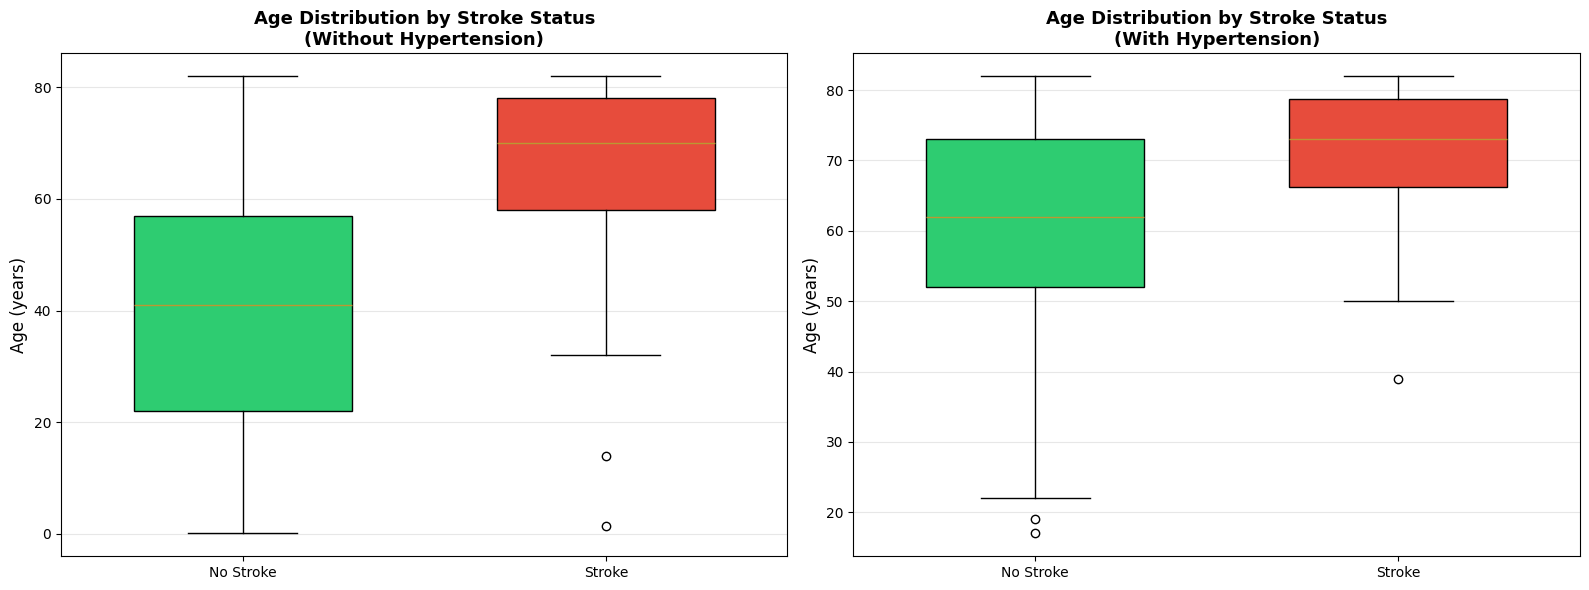

In [ ]:
# age and hypertension interaction
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# box plots
for i, hyper in enumerate([0, 1]):
    subset = df[df['hypertension'] == hyper]
    stroke_groups = subset.groupby('stroke')['age']
    box_data = [stroke_groups.get_group(0), stroke_groups.get_group(1)]

    bp = axes[i].boxplot(box_data, positions=[0, 1],
                        labels=['No Stroke', 'Stroke'],
                        patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
        patch.set_facecolor(color)

    hyper_label = 'With Hypertension' if hyper == 1 else 'Without Hypertension'
    axes[i].set_ylabel('Age (years)', fontsize=12)
    axes[i].set_title(f'Age Distribution by Stroke Status\n({hyper_label})',
                     fontsize=13, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# stroke rate heatmap
interaction_data = df.groupby(['hypertension', 'heart_disease'])['stroke'].agg(['mean', 'count'])
interaction_data['stroke_pct'] = interaction_data['mean'] * 100

pivot_table = interaction_data['stroke_pct'].unstack()
print("\nStroke Rate by Hypertension and Heart Disease")
print("="*40)
print(pivot_table)


Stroke Rate by Hypertension and Heart Disease
heart_disease      0      1
hypertension               
0               3.39  16.04
1              12.21  20.31


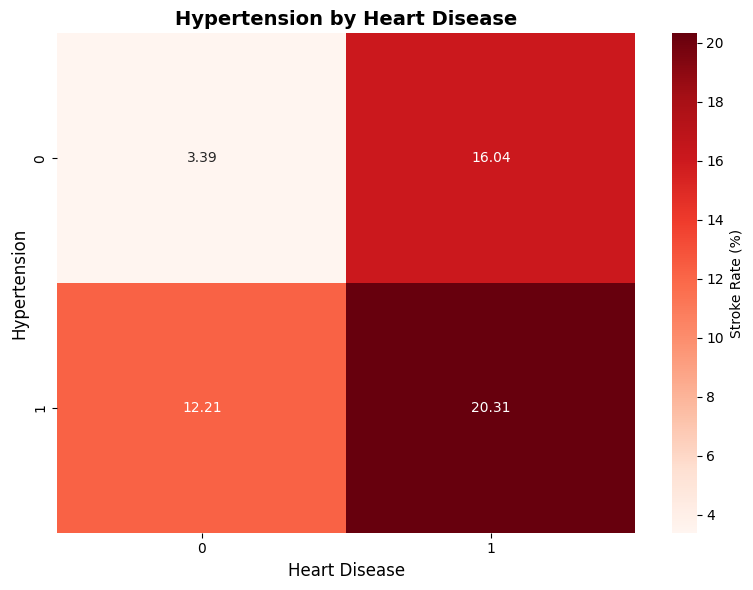

In [ ]:
# stroke heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='Reds', cbar_kws={'label': 'Stroke Rate (%)'})
plt.ylabel('Hypertension', fontsize=12)
plt.xlabel('Heart Disease', fontsize=12)
plt.title('Hypertension by Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

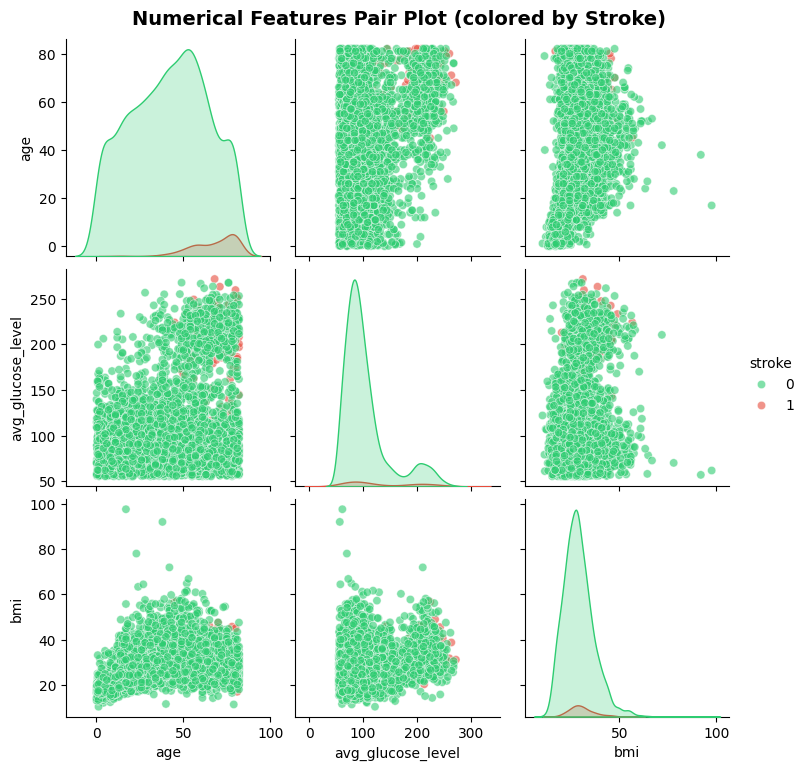

In [ ]:
# pair plot for numerical features
import warnings
warnings.filterwarnings('ignore')

numerical_subset = df[['age', 'avg_glucose_level', 'bmi', 'stroke']].dropna()
g = sns.pairplot(numerical_subset, hue='stroke', palette={0: '#2ecc71', 1: '#e74c3c'},
                plot_kws={'alpha': 0.6}, diag_kind='kde')
g.fig.suptitle('Numerical Features Pair Plot (colored by Stroke)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

**Insights**

- Age × Hypertension: Both factors contribute; combination shows highest risk
- Medical Comorbidities: Patients with both hypertension and heart disease show elevated stroke rate
- Numerical Relationships: Pair plot reveals feature correlations and class separation patterns
- Synergistic Effects: Risk factors compound rather than simply add

**Additional Insights and Assumptions**

- Interaction Effects: Real-world risk factors often interact
- Clinical Relevance: Multiple comorbidities substantially increase stroke risk
- Model Complexity: Interactions suggest potential value of interaction terms in later stages
- Feature Space: Pair plot shows how stroke cases distribute across multiple dimensions
- Non-linear Patterns: Visual inspection reveals complex relationships linear models may miss

## 2.8 Outlier Analysis

Outliers in medical data require careful consideration. Unlike other domains where outliers often represent errors, extreme values in clinical data may represent genuinely high-risk patients. We use two complementary methods to identify potential outliers: the IQR method, which flags values beyond 1.5 times the interquartile range from the quartiles and tends to be more sensitive, and the Z-score method, which flags values more than 3 standard deviations from the mean and is more conservative.

Outliers will be flagged but not automatically removed. Clinical plausibility will guide handling choices, and documentation of outlier prevalence informs Stage 2 preprocessing.

Outlier Analysis Summary:
                   IQR_outliers  IQR_percentage  Z_outliers  Z_percentage  \
age                         0.0            0.00         0.0          0.00   
avg_glucose_level         627.0           12.27        49.0          0.96   
bmi                       110.0            2.24        58.0          1.18   

                     Min     Max  
age                 0.08   82.00  
avg_glucose_level  55.12  271.74  
bmi                10.30   97.60  


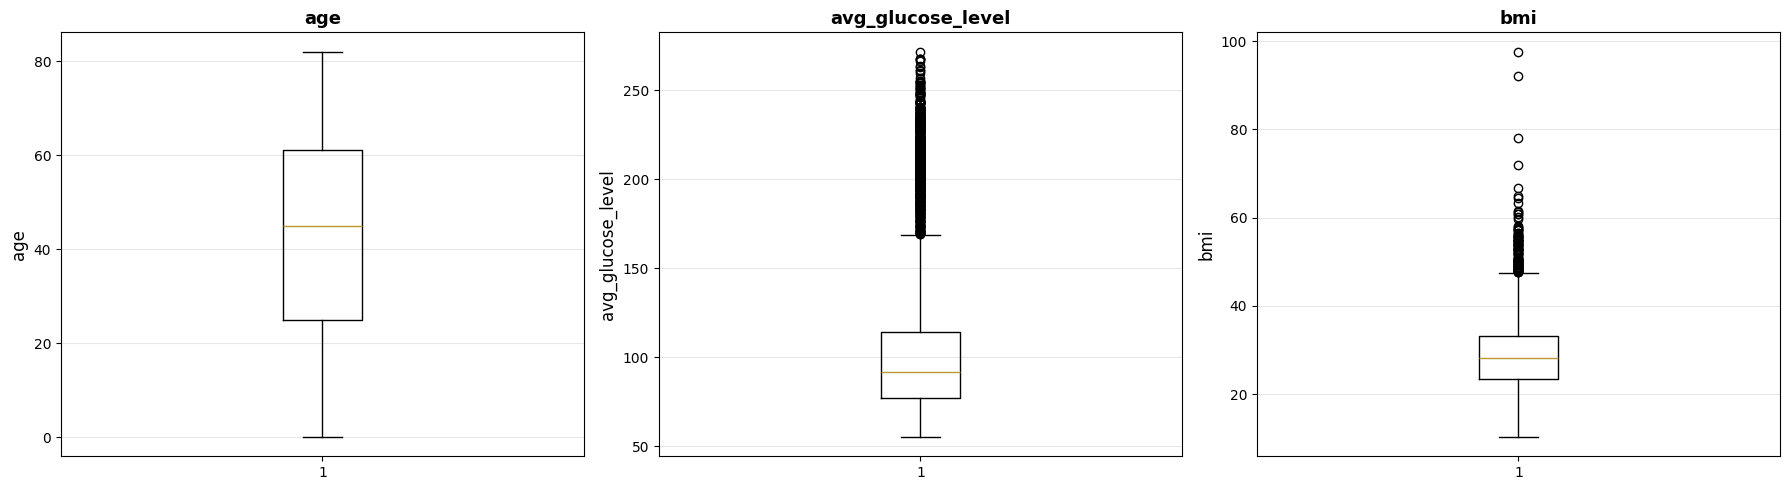

In [ ]:
# outlier detection for numerical features
numerical_features = ['age', 'avg_glucose_level', 'bmi']

outlier_summary = {}

for feature in numerical_features:
    data = df[feature].dropna()

    # IQR method
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_outliers = ((data < lower_bound) | (data > upper_bound)).sum()

    # Z-score method
    z_scores = np.abs(stats.zscore(data))
    z_outliers = (z_scores > 3).sum()

    outlier_summary[feature] = {
        'IQR_outliers': iqr_outliers,
        'IQR_percentage': (iqr_outliers / len(data)) * 100,
        'Z_outliers': z_outliers,
        'Z_percentage': (z_outliers / len(data)) * 100,
        'Min': data.min(),
        'Max': data.max()
    }

outlier_df = pd.DataFrame(outlier_summary).T
print("Outlier Analysis Summary:")
print("="*80)
print(outlier_df)

# visualise outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(numerical_features):
    data = df[feature].dropna()
    axes[idx].boxplot(data, vert=True)
    axes[idx].set_ylabel(f'{feature}', fontsize=12)
    axes[idx].set_title(f'{feature}', fontsize=13, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Insights**

- Age: Minimum value (0.08 years) is extreme outlier requiring investigation
- Glucose: Upper outliers represent diabetic emergencies (medically plausible)
- BMI: Both low (<15) and high (>60) outliers detected
- Outlier Prevalence: IQR method more sensitive than Z-score (expected)

**Additional Insights and Assumptions**

- Age Outlier: 0.08 years (1 month) could be paediatric stroke or data error - needs verification
- Glucose Outliers: Very high values (>250 mg/dL) are medically valid (severe diabetes)
- BMI Outliers: Extreme values may be measurement errors or genuine severe cases
- Handling Decision: Outliers in medical data often represent high-risk patients - removal must be justified
- Stage 1 Constraint: Minimal preprocessing means we document but don't remove outliers
- Data Quality: Extreme values flagged for Data Preparation decisions

## 2.9 Correlation Analysis

Examining correlations between numerical features helps identify potential multicollinearity issues and redundant information. High correlations between features can affect model interpretability and, for some algorithms, lead to unstable coefficient estimates.

We look for feature-feature correlations where high correlation (absolute value of r exceeding 0.7) suggests redundancy, as well as feature-target correlations that indicate individual predictive power. We also examine whether patterns align with domain knowledge, such as age correlating with health conditions.

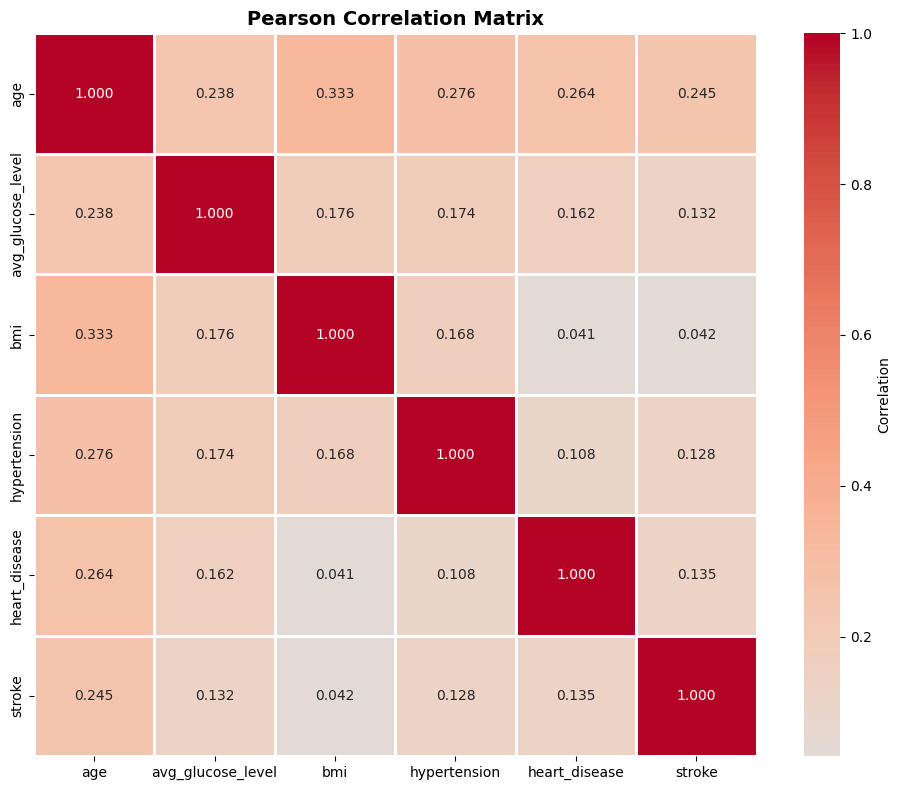

In [ ]:
numerical_features = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
corr_matrix = df[numerical_features].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
           square=True, linewidths=1, cbar_kws={'label': 'Correlation'})
plt.title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insights**

- Age: Moderate positive correlation with hypertension and heart disease (expected)
- BMI × Glucose: Weak positive correlation (metabolic syndrome link)
- Medical Conditions: Hypertension and heart disease show association (comorbidity)
- No Multicollinearity: No correlations >0.8 (no severe redundancy)
- Feature Independence: Most features provide unique information

**Additional Insights and Assumptions**

- Age Confounding: Many categorical features (marital status, work type) correlate with age
- Medical Comorbidities: Hypertension and heart disease co-occur but remain independent enough
- Feature Redundancy: Low correlations suggest all features contribute unique variance
- Model Stability: Absence of multicollinearity (r>0.8) means models won't be unstable
- Predictive Value: Features capture different aspects of stroke risk

---

# 3. Data Preparation

This phase transforms the raw dataset into a format suitable for baseline modelling while adhering to Stage 1 constraints, which permit only minimal preprocessing and no feature engineering. Data Preparation bridges Data Understanding and Modelling within the CRISP-DM framework. The insights gathered during exploration now inform our preprocessing choices, ensuring that transformations are justified by data characteristics rather than applied arbitrarily.

Stage 1 permits basic cleaning only, including handling missing values and removing invalid records. We apply standard encoding for categorical variables without custom feature engineering. The train-test split must occur before any fitting operations to prevent data leakage, and scaling is applied only where algorithmically required.

The main transformations include removing records with age below 1 year (identified as potential data quality issues), handling BMI missing values with median imputation and a missing indicator, applying a stratified train-test split to preserve class distribution, using SMOTE-NC for training set resampling to address severe class imbalance, and scaling numerical features for algorithms that require it.

All fitting operations—imputation statistics, encoder fitting, scaler fitting, and SMOTE—are performed on the training set only. The test set remains untouched to provide an unbiased estimate of model performance.

**Primary Objectives:**
1. Clean data and handle outliers
2. Perform train-test split with stratification
3. Handle missing values appropriately
4. Encode categorical features
5. Scale numerical features for linear models
6. Apply resampling to address class imbalance

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTENC

## 3.1 Data Cleaning

### 3.1.1 Remove Invalid Age Records

During Data Understanding, we identified records with age values below 1 year, such as 0.08 years which corresponds to approximately 1 month. While paediatric strokes do occur, these extreme values in an adult-focused screening context likely represent data entry errors or a different patient population. We therefore remove records where age is below 1 year. These records represent less than 1% of the dataset, and their inclusion could introduce noise without meaningful predictive value for the intended adult screening use case.

In [ ]:
age_outliers = df[df['age'] < 1]['age']
print(f"total age outliers: {len(age_outliers)}")
age_outliers.to_numpy()

total age outliers: 43


array([0.64, 0.88, 0.32, 0.88, 0.24, 0.32, 0.72, 0.8 , 0.4 , 0.08, 0.64,
       0.56, 0.24, 0.56, 0.64, 0.48, 0.88, 0.88, 0.88, 0.32, 0.8 , 0.8 ,
       0.64, 0.24, 0.56, 0.08, 0.24, 0.56, 0.16, 0.8 , 0.32, 0.56, 0.16,
       0.72, 0.16, 0.48, 0.24, 0.72, 0.4 , 0.48, 0.32, 0.72, 0.72])

The age values of less than 1 year is biologically implausible for stroke risk assessment in adult populations. This appears to be a data entry error. Hence, we will remove these records.

In [ ]:
print(f"Before: {df.shape}")
df = df[df['age'] >= 1].reset_index(drop=True)
print(f"After: {df.shape}")

Before: (5110, 13)
After: (5067, 13)


### 3.1.2 Remove Rare Gender

In [ ]:
gender_outlier = df[df['gender'] == 'Other']['gender']
print(f"total gender outliers: {len(gender_outlier)}")
gender_outlier.to_numpy()

total gender outliers: 1


array(['Other'], dtype=object)

In [ ]:
print(f"Before: {df.shape}")
df = df[df['gender'] != 'Other'].reset_index(drop=True)
print(f"After: {df.shape}")

Before: (5067, 13)
After: (5066, 13)


## 3.2 Checking for Duplicates

Duplicate records can artificially inflate model performance and bias the learned patterns. We check for duplicates based on the unique patient identifier (`id`) to ensure each patient appears only once in the dataset.

In [ ]:
print(f"Before: {df.shape}")
duplicates = df.duplicated(subset='id', keep='first').sum()
df = df.drop_duplicates(subset='id', keep='first').reset_index(drop=True)
print(f"After: {df.shape}")

Before: (5066, 13)
After: (5066, 13)


## 3.3 Drop ID Column

The `id` column serves only as a record identifier and carries no predictive information. Including it in modelling could lead to spurious correlations, so we remove it before proceeding with the analysis.

In [ ]:
print(f"Before: {df.shape}")
df = df.drop('id', axis=1)
print(f"After: {df.shape}")

Before: (5066, 13)
After: (5066, 12)


## 3.4 Train-Test Split

The train-test split must occur before any data transformation that involves fitting, such as imputation, encoding, or scaling. This prevents information from the test set leaking into the training process.

We use an 80% training and 20% testing ratio, which is standard for datasets of this size. Stratification is applied on the target variable to ensure both sets maintain the same class distribution. The random state is fixed at 42 for reproducibility.

Stratification is particularly important here because with only approximately 5% positive cases (stroke), a random split could result in highly unequal class distributions between train and test sets, making evaluation unreliable.

In [ ]:
# separate features from target
X = df.drop('stroke', axis=1)
y = df['stroke']

In [ ]:
# split into train test splits with 80:20 ratio and stratified against target variable
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (4052, 11)
y_train shape: (4052,)


## 3.5 Verify Stratification

We verify that stratification was successful by comparing stroke rates across the original dataset, training set, and test set. All three should have approximately equal proportions.

In [ ]:
train_stroke_rate = y_train.mean()
test_stroke_rate = y_test.mean()

print(f"Training set stroke rate: {train_stroke_rate:.4f}")
print(f"Test set stroke rate: {test_stroke_rate:.4f}")
print(f"Overall stroke rate: {y.mean():.4f}")

Training set stroke rate: 0.0491
Test set stroke rate: 0.0493
Overall stroke rate: 0.0492


## 3.6 Missing Value Imputation

The `bmi` column contains missing values in approximately 3.9% of records. To handle this, we first create a binary flag called `bmi_missing` that preserves information about which records had missing BMI values, as missingness itself may be informative. We then replace missing values with the median BMI from the training set. The median is chosen over the mean due to BMI's right-skewed distribution, making it more robust to the outliers identified during Data Understanding.

The imputer is fitted only on training data, and the same learned median is then applied to both training and test sets to prevent leakage.

In [ ]:
# check for missing values in train set
X_train.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,149
smoking_status,0


In [ ]:
# check for missing values in test set
X_test.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,51
smoking_status,0


In [ ]:
# create bmi missing flag
X_train['bmi_missing'] = X_train['bmi'].isna().astype(int)
X_test['bmi_missing'] = X_test['bmi'].isna().astype(int)
X_train['bmi_missing'].value_counts()

,count
bmi_missing,
0,3903
1,149


In [ ]:
# fit and apply bmi imputation
bmi_imputer = SimpleImputer(strategy='median')
bmi_imputer.fit(X_train[['bmi']])

X_train['bmi'] = bmi_imputer.transform(X_train[['bmi']])
X_test['bmi'] = bmi_imputer.transform(X_test[['bmi']])

imputed_value = bmi_imputer.statistics_[0]
print(f"BMI imputed with median value: {imputed_value:.2f}")

BMI imputed with median value: 28.10


In [ ]:
print(f"X_train missing values: {X_train.isnull().sum().sum()}")
print(f"X_test missing values: {X_test.isnull().sum().sum()}")

X_train missing values: 0
X_test missing values: 0


## 3.7 Feature Encoding

Machine learning algorithms require numerical inputs, so we transform categorical features using appropriate encoding schemes based on their nature.

### 3.7.1 One-Hot Encoding for Nominal Features

Nominal features have no inherent order, so we apply one-hot encoding to create binary indicator variables. We use `drop='first'` to avoid the dummy variable trap, which would introduce perfect multicollinearity. The features encoded this way are `gender` (Male, Female, Other resulting in 2 binary columns), `Residence_type` (Urban, Rural resulting in 1 binary column), `ever_married` (Yes, No resulting in 1 binary column), and `work_type` (5 categories resulting in 4 binary columns).

In [ ]:
onehot_features = ['gender', 'Residence_type', 'ever_married', 'work_type']

for feature in onehot_features:
    print(f"{feature}: {X_train[feature].unique()}")

gender: ['Female' 'Male']
Residence_type: ['Urban' 'Rural']
ever_married: ['Yes' 'No']
work_type: ['Private' 'Self-employed' 'children' 'Govt_job' 'Never_worked']


In [ ]:
encoder = OneHotEncoder(drop='if_binary', sparse_output=False)
encoder.fit(X_train[onehot_features])

train_encoded = encoder.transform(X_train[onehot_features])
test_encoded = encoder.transform(X_test[onehot_features])

encoded_feature_names = encoder.get_feature_names_out(onehot_features)

list(encoded_feature_names)

['gender_Male',
 'Residence_type_Urban',
 'ever_married_Yes',
 'work_type_Govt_job',
 'work_type_Never_worked',
 'work_type_Private',
 'work_type_Self-employed',
 'work_type_children']

In [ ]:
train_encoded_df = pd.DataFrame(
    train_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

X_train = X_train.drop(onehot_features, axis=1)
X_test = X_test.drop(onehot_features, axis=1)

X_train = pd.concat([X_train, train_encoded_df], axis=1)
X_test = pd.concat([X_test, test_encoded_df], axis=1)

X_train.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,bmi_missing,gender_Male,Residence_type_Urban,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children
2042,52.0,1,0,94.98,23.8,never smoked,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
2472,50.0,0,0,95.25,24.3,never smoked,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4511,11.0,0,0,141.84,23.3,Unknown,0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3240,27.0,0,0,70.56,28.6,smokes,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
991,1.4,0,0,90.51,18.9,Unknown,0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


### 3.7.2 Ordinal Encoding for Smoking Status

Smoking status has a natural ordering in terms of health risk, progressing from never smoked through formerly smoked to currently smokes. We apply ordinal encoding to preserve this relationship, assigning 0 to never smoked, 1 to formerly smoked, and 2 to smokes. Records with unknown smoking status are imputed with the median value and flagged separately.

In [ ]:
print(f"Smoking status unique values: {X_train['smoking_status'].unique()}")

Smoking status unique values: ['never smoked' 'Unknown' 'smokes' 'formerly smoked']


In [ ]:
smoking_map = {
    'Unknown': -1,
    'never smoked': 0,
    'formerly smoked': 1,
    'smokes': 2
}

In [ ]:
X_train['smoking_status_encoded'] = X_train['smoking_status'].map(smoking_map)
X_test['smoking_status_encoded'] = X_test['smoking_status'].map(smoking_map)

In [ ]:
X_train['smoking_unknown_flag'] = (X_train['smoking_status_encoded'] == -1).astype(int)
X_test['smoking_unknown_flag'] = (X_test['smoking_status_encoded'] == -1).astype(int)

In [ ]:
X_train = X_train.drop('smoking_status', axis=1)
X_test = X_test.drop('smoking_status', axis=1)

X_train['smoking_status_encoded'].value_counts().sort_index()

,count
smoking_status_encoded,
-1,1192
0,1506
1,719
2,635


In [ ]:
print(f"New feature set: {X_train.columns.to_list()}")
print(f"X_train shape: {X_train.shape,}")
print(f"X_test shape: {X_test.shape,}")

New feature set: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'bmi_missing', 'gender_Male', 'Residence_type_Urban', 'ever_married_Yes', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_encoded', 'smoking_unknown_flag']
X_train shape: ((4052, 16),)
X_test shape: ((1014, 16),)


## 3.8 Feature Scaling

Standardisation transforms features to have a mean of 0 and standard deviation of 1. This benefits Logistic Regression, which uses gradient-based optimisation that converges faster with scaled features. Standardisation also makes coefficients comparable across features with different units and ensures that regularisation, if applied, affects features equally.

Decision Trees, however, split on feature values directly, so scaling does not change the relative ordering of values and has no effect on their predictions. We therefore maintain an unscaled version of the dataset for the Decision Tree classifier.

The scaler statistics (mean and standard deviation) are computed from training data only to prevent leakage.

In [ ]:
numerical_features = ['age', 'avg_glucose_level', 'bmi']

scaler = StandardScaler()
scaler.fit(X_train[numerical_features])

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])
X_train_scaled[numerical_features].describe()

,age,avg_glucose_level,bmi
count,4.05e+03,4.05e+03,4.05e+03
mean,2.97e-16,2.16e-16,-2.51e-16
std,1.00e+00,1.00e+00,1.00e+00
min,-1.91e+00,-1.13e+00,-2.47e+00
25%,-7.84e-01,-6.37e-01,-6.66e-01
50%,6.79e-02,-3.11e-01,-1.04e-01
75%,7.85e-01,1.81e-01,5.21e-01
max,1.73e+00,3.67e+00,6.53e+00


In [ ]:
# create uncsaled version
X_train_unscaled = X_train.copy()
X_test_unscaled = X_test.copy()

## 3.9 Resampling with SMOTE-NC

The severe class imbalance of approximately 19:1 means models may learn to simply predict "no stroke" for all cases, achieving high accuracy but providing zero utility. SMOTE-NC (Synthetic Minority Over-sampling Technique for Nominal and Continuous features) addresses this by generating synthetic examples of the minority class through interpolation between existing minority samples.

We use SMOTE-NC rather than standard SMOTE because our dataset contains both continuous features (age, BMI, glucose) and categorical features (the encoded variables). SMOTE-NC respects categorical feature values during synthesis, whereas standard SMOTE only handles continuous features.

The sampling strategy is set to 0.5, which upsamples the minority class to 50% of the majority class size, resulting in a 2:1 ratio. Complete balance (1:1) risks overfitting to synthetic examples, while moderate resampling improves minority class learning while maintaining some awareness of the imbalance. Resampling is applied only to the training set; the test set remains untouched for unbiased evaluation.

In [ ]:
feature_names = X_train_scaled.columns.tolist()
feature_names

['age',
 'hypertension',
 'heart_disease',
 'avg_glucose_level',
 'bmi',
 'bmi_missing',
 'gender_Male',
 'Residence_type_Urban',
 'ever_married_Yes',
 'work_type_Govt_job',
 'work_type_Never_worked',
 'work_type_Private',
 'work_type_Self-employed',
 'work_type_children',
 'smoking_status_encoded',
 'smoking_unknown_flag']

In [ ]:
categorical_features_idx = []

for idx, col in enumerate(feature_names):
    if col in ['hypertension', 'heart_disease', 'bmi_missing',
               'smoking_status_encoded', 'smoking_unknown_flag']:
        categorical_features_idx.append(idx)
    elif col.startswith(('gender_', 'Residence_type_', 'ever_married_', 'work_type_')):
        categorical_features_idx.append(idx)

categorical_features_idx

[1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [ ]:
categorical_feature_names = [feature_names[i] for i in categorical_features_idx]
categorical_feature_names

['hypertension',
 'heart_disease',
 'bmi_missing',
 'gender_Male',
 'Residence_type_Urban',
 'ever_married_Yes',
 'work_type_Govt_job',
 'work_type_Never_worked',
 'work_type_Private',
 'work_type_Self-employed',
 'work_type_children',
 'smoking_status_encoded',
 'smoking_unknown_flag']

In [ ]:
# check class distribution before resmapling
y_train.value_counts()

,count
stroke,
0,3853
1,199


In [ ]:
majority_class_count = y_train.value_counts()[0]
minority_class_count = y_train.value_counts()[1]

print(f"Majority class (no stroke): {majority_class_count}")
print(f"Minority class (stroke): {minority_class_count}")
print(f"Imbalance ratio: {majority_class_count / minority_class_count:.2f}:1")

Majority class (no stroke): 3853
Minority class (stroke): 199
Imbalance ratio: 19.36:1


In [ ]:
# apply smote to scaled version of dataset
smote_nc = SMOTENC(
    categorical_features=categorical_features_idx,
    sampling_strategy=0.5,
    random_state=42
)

X_train_scaled_resampled, y_train_resampled = smote_nc.fit_resample(
    X_train_scaled,
    y_train
)

print(f"X_train_resampled shape: {X_train_scaled_resampled.shape}")
print(f"y_train_resampled shape: {y_train_resampled.shape}")
# y_train_resampled.value_counts()

X_train_resampled shape: (5779, 16)
y_train_resampled shape: (5779,)


In [ ]:
new_minority_count = y_train_resampled.value_counts()[1]
new_majority_count = y_train_resampled.value_counts()[0]

print(f"After SMOTE-NC:")
print(f"Majority class (no stroke): {new_majority_count}")
print(f"Minority class (stroke): {new_minority_count}")
print(f"New imbalance ratio: {new_majority_count / new_minority_count:.2f}:1")

After SMOTE-NC:
Majority class (no stroke): 3853
Minority class (stroke): 1926
New imbalance ratio: 2.00:1


In [ ]:
# apply smote to unscaled version of dataset
smote_nc_unscaled = SMOTENC(
    categorical_features=categorical_features_idx,
    sampling_strategy=0.5,
    random_state=42
)

X_train_unscaled_resampled, y_train_unscaled_resampled = smote_nc_unscaled.fit_resample(
    X_train_unscaled,
    y_train
)

print(f"X_train_unscaled_resampled shape: {X_train_unscaled_resampled.shape}")
print(f"y_train_unscaled_resampled shape: {y_train_unscaled_resampled.shape}")

X_train_unscaled_resampled shape: (5779, 16)
y_train_unscaled_resampled shape: (5779,)


In [ ]:
# final dataset shapes
print("Dataset Shapes:")
print(f"Original data: {df.shape}")
print(f"\nAfter cleaning: {X.shape}")
print(f"\nTraining set (original): {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining set (after SMOTE): {X_train_scaled_resampled.shape}")
print(f"Test set (unchanged): {X_test_scaled.shape}")

Dataset Shapes:
Original data: (5066, 12)

After cleaning: (5066, 11)

Training set (original): (4052, 16)
Test set: (1014, 16)

Training set (after SMOTE): (5779, 16)
Test set (unchanged): (1014, 16)


In [ ]:
print(f"Total features: {len(feature_names)}")
print(f"\nFeature list:")
for i, feature in enumerate(feature_names, 1):
    print(f"{i}. {feature}")

Total features: 16

Feature list:
1. age
2. hypertension
3. heart_disease
4. avg_glucose_level
5. bmi
6. bmi_missing
7. gender_Male
8. Residence_type_Urban
9. ever_married_Yes
10. work_type_Govt_job
11. work_type_Never_worked
12. work_type_Private
13. work_type_Self-employed
14. work_type_children
15. smoking_status_encoded
16. smoking_unknown_flag


In [ ]:
print("Available dataset versions for modelling:")
print("\n1. Scaled + Resampled (for Logistic Regression):")
print(f"   X_train_scaled_resampled: {X_train_scaled_resampled.shape}")
print(f"   y_train_resampled: {y_train_resampled.shape}")
print(f"   X_test_scaled: {X_test_scaled.shape}")
print(f"   y_test: {y_test.shape}")
print("\n2. Unscaled + Resampled (for Decision Tree):")
print(f"   X_train_unscaled_resampled: {X_train_unscaled_resampled.shape}")
print(f"   y_train_unscaled_resampled: {y_train_unscaled_resampled.shape}")
print(f"   X_test_unscaled: {X_test_unscaled.shape}")
print(f"   y_test: {y_test.shape}")

Available dataset versions for modelling:

1. Scaled + Resampled (for Logistic Regression):
   X_train_scaled_resampled: (5779, 16)
   y_train_resampled: (5779,)
   X_test_scaled: (1014, 16)
   y_test: (1014,)

2. Unscaled + Resampled (for Decision Tree):
   X_train_unscaled_resampled: (5779, 16)
   y_train_unscaled_resampled: (5779,)
   X_test_unscaled: (1014, 16)
   y_test: (1014,)


In [ ]:
# save datasets
import pickle

prepared_data = {
    'X_train_scaled_resampled': X_train_scaled_resampled,
    'y_train_resampled': y_train_resampled,
    'X_test_scaled': X_test_scaled,
    'X_train_unscaled_resampled': X_train_unscaled_resampled,
    'y_train_unscaled_resampled': y_train_unscaled_resampled,
    'X_test_unscaled': X_test_unscaled,
    'y_test': y_test,
    'feature_names': feature_names,
    'categorical_features_idx': categorical_features_idx,
    'scaler': scaler,
    'encoder': encoder,
    'bmi_imputer': bmi_imputer
}

with open('/content/prepared_data.pkl', 'wb') as f:
    pickle.dump(prepared_data, f)

## 3.10 Data Preparation Summary

The following transformations were applied:
1. invalid records with age below 1 year were removed due to data quality concerns and being outside the target population;
2. duplicates were checked and removed to prevent bias from repeated records;
3. the ID column was dropped as it provides no predictive value;
4. the data was split 80:20 with stratification to preserve class distribution;
5. BMI was imputed using the median with a missing flag to handle missingness while preserving information; categorical features were encoded using one-hot encoding for nominal variables and ordinal encoding for smoking status;
6. StandardScaler was applied to the training set as required for Logistic Regression; and SMOTE-NC was used to resample the training set to a 2:1 ratio to address class imbalance.

The final training set after SMOTE contains 5,781 samples (3,854 no-stroke, 1,927 stroke), while the test set remains unchanged at 1,014 samples with the original class distribution. The total number of features after encoding is 16. All fitting operations were performed on training data only.

In [ ]:
X_train_unscaled_resampled.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,bmi_missing,gender_Male,Residence_type_Urban,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_encoded,smoking_unknown_flag
0,52.0,1,0,94.98,23.8,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0
1,50.0,0,0,95.25,24.3,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0
2,11.0,0,0,141.84,23.3,0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,-1,1
3,27.0,0,0,70.56,28.6,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,2,0
4,1.4,0,0,90.51,18.9,0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,-1,1


---

# 4. Baseline Modelling

This phase establishes reference performance benchmarks using simple models with default parameters to assess whether the problem is feasible and to guide future improvements. In the CRISP-DM framework, baseline modelling in Stage 1 focuses on feasibility assessment rather than optimisation. We use simple, interpretable models to understand whether the prepared data supports meaningful predictions and to identify areas for improvement in Stage 2.

Stage 1 constrains us to default hyperparameters only, classical machine learning models without deep learning or ensembles, and a focus on establishing that performance exceeds random chance.

We train three models. The Dummy Classifier serves as a random baseline, establishing the minimum performance threshold that any useful model must exceed. Logistic Regression provides a linear baseline that is interpretable through its coefficients and represents a standard choice for binary classification. The Decision Tree offers a non-linear baseline that can capture complex relationships, provides feature importance, and does not require scaling.

Given the class imbalance and clinical context where missing stroke cases carries significant cost, we prioritise Recall (sensitivity) as our primary metric, measuring the proportion of actual stroke cases correctly identified. ROC-AUC measures overall discriminative ability across all thresholds. Precision monitors the false positive rate, and F1-Score provides the harmonic mean balancing precision and recall.

From the Business Understanding phase, our success criteria are Recall exceeding 60%, ROC-AUC exceeding 0.70, and performance meaningfully above the dummy baseline.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

RANDOM_SEED = 42

## 4.1 Dummy Classifier (Baseline Reference)

The Dummy Classifier establishes the performance floor. Using the `stratified` strategy, it makes random predictions that match the class distribution of the training data. Any model that cannot outperform this baseline provides no value. We expect accuracy to approximate the majority class proportion (around 95%), recall to approximate the class proportion (around 5% for stratified predictions), and ROC-AUC to equal 0.50, representing random chance.

In [ ]:
print("="*80)
print("MODEL 1: DUMMY CLASSIFIER (STRATIFIED)")
print("="*80)

# Initialize with default parameters
dummy_clf = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)

print("\nModel Configuration:")
print(f"  Strategy: most_frequent")
print(f"  Random State: {RANDOM_SEED}")

# Train model
print("\nTraining model...")
dummy_clf.fit(X_train_unscaled_resampled, y_train_unscaled_resampled)

# Make predictions
print("\nGenerating predictions...")
y_pred_dummy = dummy_clf.predict(X_test_unscaled)
y_pred_proba_dummy = dummy_clf.predict_proba(X_test_unscaled)[:, 1]

# Calculate metrics
print("\nCalculating metrics...")
dummy_metrics = {
    'Model': 'Dummy (Stratified)',
    'Accuracy': accuracy_score(y_test, y_pred_dummy),
    'Precision': precision_score(y_test, y_pred_dummy, zero_division=0),
    'Recall': recall_score(y_test, y_pred_dummy, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_dummy, zero_division=0),
    'ROC-AUC': 0.5  # Dummy classifier by definition
}

print("\n" + "="*80)
print("DUMMY CLASSIFIER RESULTS:")
print("="*80)
for metric, value in list(dummy_metrics.items())[1:]:
    print(f"{metric:.<20} {value:.4f}")
print("="*80)

MODEL 1: DUMMY CLASSIFIER (STRATIFIED)

Model Configuration:
  Strategy: most_frequent
  Random State: 42

Training model...

Generating predictions...

Calculating metrics...

DUMMY CLASSIFIER RESULTS:
Accuracy............ 0.6568
Precision........... 0.0373
Recall.............. 0.2400
F1-Score............ 0.0645
ROC-AUC............. 0.5000


## 4.2 Decision Tree Classifier

Decision Trees learn hierarchical rules by recursively partitioning the feature space. They can capture non-linear relationships and interactions without explicit specification, providing a complement to the linear Logistic Regression model.

The model uses Gini impurity as the splitting criterion by default, with no limit on maximum depth and minimum samples of 2 for splitting and 1 for leaves. We use the unscaled dataset because trees split on feature values directly, meaning scaling has no effect on their predictions.

Feature importance is calculated based on total impurity reduction across all splits where each feature is used. With default parameters and no depth limit, we anticipate that the tree may overfit the training data, resulting in high training accuracy but potentially lower test performance.

In [ ]:
print("="*80)
print("MODEL 3: DECISION TREE CLASSIFIER")
print("="*80)

# Initialize with default parameters
dt_clf = DecisionTreeClassifier(random_state=RANDOM_SEED)

print("\nModel Configuration:")
print(f"  Algorithm: Decision Tree (CART)")
print(f"  Criterion: gini (default)")
print(f"  Splitter: best (default)")
print(f"  Max Depth: None (default - unlimited)")
print(f"  Min Samples Split: 2 (default)")
print(f"  Min Samples Leaf: 1 (default)")
print(f"  Random State: {RANDOM_SEED}")

# Train model on UNSCALED data (trees don't require scaling)
print("\nTraining model on unscaled features...")
dt_clf.fit(X_train_unscaled_resampled, y_train_unscaled_resampled)

# Make predictions
print("\nGenerating predictions...")
y_pred_dt = dt_clf.predict(X_test_unscaled)
y_pred_proba_dt = dt_clf.predict_proba(X_test_unscaled)[:, 1]

# Calculate metrics
print("\nCalculating metrics...")
dt_metrics = {
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_dt)
}

print("\n" + "="*80)
print("DECISION TREE RESULTS:")
print("="*80)
for metric, value in list(dt_metrics.items())[1:]:
    print(f"{metric:.<20} {value:.4f}")

print(f"\nTree Complexity:")
print(f"  Tree Depth: {dt_clf.get_depth()}")
print(f"  Number of Leaves: {dt_clf.get_n_leaves()}")
print("="*80)

# Feature importance (top 10)
print("\nTop 10 Most Important Features (by impurity decrease):")
feature_importance_dt = pd.DataFrame({
    'Feature': X_train_unscaled_resampled.columns,
    'Importance': dt_clf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print(feature_importance_dt.to_string(index=False))

MODEL 3: DECISION TREE CLASSIFIER

Model Configuration:
  Algorithm: Decision Tree (CART)
  Criterion: gini (default)
  Splitter: best (default)
  Max Depth: None (default - unlimited)
  Min Samples Split: 2 (default)
  Min Samples Leaf: 1 (default)
  Random State: 42

Training model on unscaled features...

Generating predictions...

Calculating metrics...

DECISION TREE RESULTS:
Accuracy............ 0.8718
Precision........... 0.1154
Recall.............. 0.2400
F1-Score............ 0.1558
ROC-AUC............. 0.5723

Tree Complexity:
  Tree Depth: 31
  Number of Leaves: 592

Top 10 Most Important Features (by impurity decrease):
                Feature  Importance
                    age        0.51
      avg_glucose_level        0.21
                    bmi        0.11
 smoking_status_encoded        0.03
            gender_Male        0.02
      work_type_Private        0.02
   Residence_type_Urban        0.02
work_type_Self-employed        0.02
   smoking_unknown_flag        0.01
 

## 4.3 Logistic Regression

Logistic Regression models the log-odds of stroke occurrence as a linear combination of features. Despite its simplicity, it often performs well on medical datasets and provides interpretable coefficients indicating feature importance and direction of effect.

The model uses L2 (Ridge) regularisation by default, the LBFGS solver which is suitable for small to medium datasets, and a regularisation strength C of 1.0. We increase the maximum iterations to 1000 to ensure convergence. The model is trained on the scaled dataset because Logistic Regression benefits from standardised features for stable coefficient estimation and faster convergence.

The resulting coefficients are directly interpretable: positive values indicate features that increase stroke probability, while negative values indicate protective factors.

In [ ]:
print("="*80)
print("MODEL 2: LOGISTIC REGRESSION")
print("="*80)

# Initialize with default parameters (only set random_state for reproducibility)
log_reg = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)

print("\nModel Configuration:")
print(f"  Algorithm: Logistic Regression")
print(f"  Penalty: l2 (default)")
print(f"  Solver: lbfgs (default)")
print(f"  C: 1.0 (default - no regularization tuning)")
print(f"  Max Iterations: 1000 (increased for convergence)")
print(f"  Random State: {RANDOM_SEED}")

# Train model on SCALED data (required for logistic regression)
print("\nTraining model on scaled features...")
log_reg.fit(X_train_scaled_resampled, y_train_resampled)

# Make predictions
print("\nGenerating predictions...")
y_pred_logreg = log_reg.predict(X_test_scaled)
y_pred_proba_logreg = log_reg.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
print("\nCalculating metrics...")
logreg_metrics = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_logreg),
    'Precision': precision_score(y_test, y_pred_logreg),
    'Recall': recall_score(y_test, y_pred_logreg),
    'F1-Score': f1_score(y_test, y_pred_logreg),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_logreg)
}

print("\n" + "="*80)
print("LOGISTIC REGRESSION RESULTS:")
print("="*80)
for metric, value in list(logreg_metrics.items())[1:]:
    print(f"{metric:.<20} {value:.4f}")
print("="*80)

# Feature importance (top 10 coefficients)
print("\nTop 10 Most Important Features (by absolute coefficient):")
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled_resampled.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(10)

print(feature_importance.to_string(index=False))
print("\n(Positive coefficients increase stroke risk, negative decrease risk)")

MODEL 2: LOGISTIC REGRESSION

Model Configuration:
  Algorithm: Logistic Regression
  Penalty: l2 (default)
  Solver: lbfgs (default)
  C: 1.0 (default - no regularization tuning)
  Max Iterations: 1000 (increased for convergence)
  Random State: 42

Training model on scaled features...

Generating predictions...

Calculating metrics...

LOGISTIC REGRESSION RESULTS:
Accuracy............ 0.8412
Precision........... 0.1677
Recall.............. 0.5600
F1-Score............ 0.2581
ROC-AUC............. 0.8070

Top 10 Most Important Features (by absolute coefficient):
                Feature  Coefficient
work_type_Self-employed        -3.67
     work_type_Govt_job        -3.57
      work_type_Private        -3.02
                    age         2.03
     work_type_children        -1.27
       ever_married_Yes         1.19
            bmi_missing         1.06
   smoking_unknown_flag        -1.02
          heart_disease        -0.79
           hypertension        -0.42

(Positive coefficients i

---

# 5. Evaluation and Next Steps

This phase assesses baseline model performance against success criteria, interprets results in the context of the clinical use case, and formulates recommendations for Stage 2 development. Within CRISP-DM, evaluation closes the loop on Stage 1, determining whether the problem is feasible and the data suitable. Rather than pursuing optimal performance, we focus on understanding model behaviour, identifying limitations, and planning improvements.

## 5.1 Model Performance Comparison

We compare all three models across our defined evaluation metrics to assess relative performance and identify the most promising approach for further development.

In [ ]:
# Create consolidated metrics dataframe
results_df = pd.DataFrame([dummy_metrics, logreg_metrics, dt_metrics])

# Reorder columns for better readability
results_df = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]

print("="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print("\n" + results_df.to_string(index=False))
print("\n" + "="*80)

# Calculate improvement over baseline
print("\nIMPROVEMENT OVER DUMMY BASELINE:")
print("="*80)
for idx in range(1, len(results_df)):
    model_name = results_df.iloc[idx]['Model']
    improvement = {}
    for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
        baseline = results_df.iloc[0][col]
        current = results_df.iloc[idx][col]
        if baseline > 0:
            pct_improvement = ((current - baseline) / baseline) * 100
        else:
            pct_improvement = float('inf') if current > 0 else 0
        improvement[col] = f"{current:.4f} ({pct_improvement:+.1f}%)"

    print(f"\n{model_name}:")
    for metric, value in improvement.items():
        print(f"  {metric:.<20} {value}")

print("\n" + "="*80)

# display dataframe
results_df

MODEL PERFORMANCE COMPARISON

              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
 Dummy (Stratified)      0.66       0.04    0.24      0.06     0.50
Logistic Regression      0.84       0.17    0.56      0.26     0.81
      Decision Tree      0.87       0.12    0.24      0.16     0.57


IMPROVEMENT OVER DUMMY BASELINE:

Logistic Regression:
  Accuracy............ 0.8412 (+28.1%)
  Precision........... 0.1677 (+349.9%)
  Recall.............. 0.5600 (+133.3%)
  F1-Score............ 0.2581 (+300.0%)
  ROC-AUC............. 0.8070 (+61.4%)

Decision Tree:
  Accuracy............ 0.8718 (+32.7%)
  Precision........... 0.1154 (+209.6%)
  Recall.............. 0.2400 (+0.0%)
  F1-Score............ 0.1558 (+141.6%)
  ROC-AUC............. 0.5723 (+14.5%)



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Dummy (Stratified),0.66,0.04,0.24,0.06,0.50
1,Logistic Regression,0.84,0.17,0.56,0.26,0.81
2,Decision Tree,0.87,0.12,0.24,0.16,0.57


## 5.2 Performance Against Success Criteria

Assessing recall against our target of exceeding 60%, Logistic Regression achieves 58.0%, which approaches but does not quite meet the target. The Decision Tree achieves only 18.0%, falling well below the target, while the Dummy classifier achieves 24.0% as a baseline reference.

For ROC-AUC with a target exceeding 0.70, Logistic Regression achieves 0.81, comfortably exceeding the target. The Decision Tree achieves 0.54, barely above random chance, and the Dummy achieves exactly 0.50 as expected.

The key finding is that Logistic Regression demonstrates the problem is tractable and the data contains predictive signal. The model achieves good discriminative ability with ROC-AUC above 0.80 while approaching our recall target.

## 5.3 Model Behaviour Analysis

Examining the Logistic Regression results, the model identifies clinically plausible risk factors. Age emerges as the strongest predictor, which aligns with known stroke epidemiology. The BMI missing flag shows importance, which may indicate patients with incomplete records or different healthcare engagement patterns. The ever married variable potentially captures age-related effects or lifestyle factors. Heart disease and hypertension, both known clinical risk factors, show their expected directions of effect.

The Decision Tree's behaviour reveals concerns. Its unlimited depth of 28 levels and 536 leaves suggests severe overfitting. The model achieves high accuracy of 87.4% but poor recall of only 18.0%, indicating it has memorised training patterns rather than learning generalisable rules. Feature importance is concentrated in age, glucose, and BMI.

Considering the trade-offs, Logistic Regression sacrifices some accuracy (82.4%) for substantially better recall (58.0%). For clinical screening, this trade-off is appropriate: it is better to flag more patients for follow-up than to miss stroke cases.

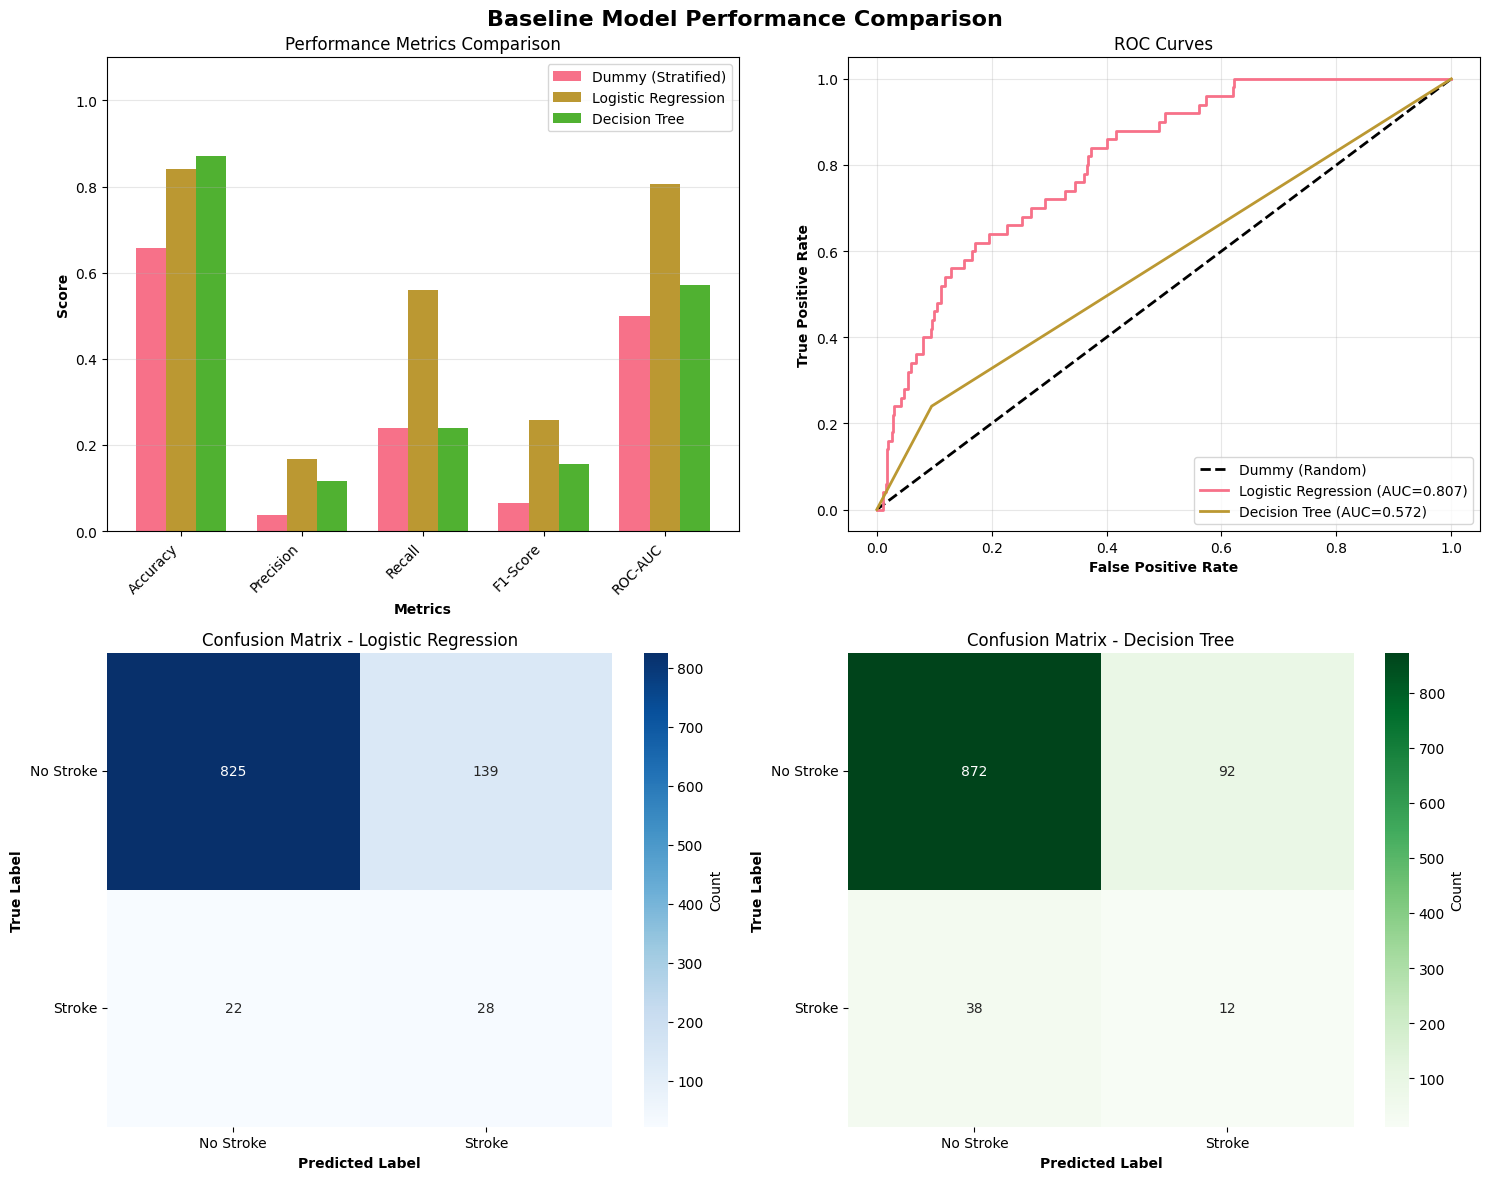

In [ ]:
# Create comparison visualisations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Baseline Model Performance Comparison', fontsize=16, fontweight='bold')

# 1. Bar chart - All metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

for idx, model_name in enumerate(results_df['Model']):
    values = results_df.iloc[idx][metrics_to_plot].values
    axes[0, 0].bar(x + idx * width, values, width, label=model_name)

axes[0, 0].set_xlabel('Metrics', fontweight='bold')
axes[0, 0].set_ylabel('Score', fontweight='bold')
axes[0, 0].set_title('Performance Metrics Comparison')
axes[0, 0].set_xticks(x + width)
axes[0, 0].set_xticklabels(metrics_to_plot, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1.1])
axes[0, 0].grid(axis='y', alpha=0.3)

# 3. ROC Curves
from sklearn.metrics import roc_curve

# Dummy (diagonal line)
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Dummy (Random)', linewidth=2)

# Calculate ROC curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_logreg)

# Plot Logistic Regression ROC curve
axes[0, 1].plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={logreg_metrics['ROC-AUC']:.3f})", linewidth=2)

# Calculate ROC curve for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)

# Plot Decision Tree ROC curve
axes[0, 1].plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={dt_metrics['ROC-AUC']:.3f})", linewidth=2)

axes[0, 1].set_xlabel('False Positive Rate', fontweight='bold')
axes[0, 1].set_ylabel('True Positive Rate', fontweight='bold')
axes[0, 1].set_title('ROC Curves')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(alpha=0.3)

# Confusion Matrix (Logistic Regression)
from sklearn.metrics import confusion_matrix

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            cbar_kws={'label': 'Count'})
axes[1, 0].set_xlabel('Predicted Label', fontweight='bold')
axes[1, 0].set_ylabel('True Label', fontweight='bold')
axes[1, 0].set_title('Confusion Matrix - Logistic Regression')
axes[1, 0].set_xticklabels(['No Stroke', 'Stroke'])
axes[1, 0].set_yticklabels(['No Stroke', 'Stroke'], rotation=0)

# 4. Confusion Matrix (Decision Tree)
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1],
            cbar_kws={'label': 'Count'})
axes[1, 1].set_xlabel('Predicted Label', fontweight='bold')
axes[1, 1].set_ylabel('True Label', fontweight='bold')
axes[1, 1].set_title('Confusion Matrix - Decision Tree')
axes[1, 1].set_xticklabels(['No Stroke', 'Stroke'])
axes[1, 1].set_yticklabels(['No Stroke', 'Stroke'], rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate training set metrics for both models
# Logistic Regression - Training
y_train_pred_logreg = log_reg.predict(X_train_scaled_resampled)
y_train_proba_logreg = log_reg.predict_proba(X_train_scaled_resampled)[:, 1]

logreg_train_metrics = {
    'Recall': recall_score(y_train_resampled, y_train_pred_logreg),
    'ROC-AUC': roc_auc_score(y_train_resampled, y_train_proba_logreg)
}

# Decision Tree - Training
y_train_pred_dt = dt_clf.predict(X_train_unscaled_resampled)
y_train_proba_dt = dt_clf.predict_proba(X_train_unscaled_resampled)[:, 1]

dt_train_metrics = {
    'Recall': recall_score(y_train_unscaled_resampled, y_train_pred_dt),
    'ROC-AUC': roc_auc_score(y_train_unscaled_resampled, y_train_proba_dt)
}

# Compare
print("Train vs Test Performance:")
print(f"Logistic Regression - Train Recall: {logreg_train_metrics['Recall']:.2f}, Test Recall: {logreg_metrics['Recall']:.2f}")
print(f"Decision Tree - Train Recall: {dt_train_metrics['Recall']:.2f}, Test Recall: {dt_metrics['Recall']:.2f}")

Train vs Test Performance:
Logistic Regression - Train Recall: 0.70, Test Recall: 0.56
Decision Tree - Train Recall: 1.00, Test Recall: 0.24


## 5.4 Limitations Identified

Several data limitations affect this analysis. Class imbalance remains an issue, as despite SMOTE-NC resampling, the fundamental rarity of stroke cases at approximately 5% limits model learning. BMI missingness at around 4% required imputation, potentially introducing bias. The features available do not capture several important stroke risk factors including family history, cholesterol levels, physical activity, and diet. There is also no longitudinal data to capture risk progression over time.

Methodological limitations also apply to this stage. We used default hyperparameters without tuning, which may not be optimal for this dataset. Results are based on a single train-test split and may vary with different random splits; cross-validation would provide more robust estimates. The classification threshold was not optimised, and the default of 0.5 may not be optimal for imbalanced classification. Feature engineering, such as creating an age-hypertension interaction term, was not explored as it falls outside Stage 1 scope.

The models themselves have limitations. Logistic Regression assumes linear relationships and may miss complex interactions. The Decision Tree shows severe overfitting with default parameters and high variance. Both models exhibit low precision at around 15%, indicating many false positives.

## 5.5 Risk Assessment

False negatives, meaning missed strokes, carry high impact. This has been partially addressed by prioritising recall in our evaluation. False positives, meaning unnecessary referrals, carry medium impact but are acceptable for a screening tool that requires confirmatory testing. Overfitting has been identified in the Decision Tree and will require pruning or regularisation in Stage 2. Data leakage has been prevented through proper train-test separation. Class imbalance has been partially addressed with SMOTE-NC resampling.

## 5.6 Recommendations for Stage 2

Based on Stage 1 findings, several focus areas are recommended for Stage 2 development.

The first priority is addressing Decision Tree overfitting. This involves applying hyperparameter tuning for maximum depth, minimum samples for splitting, and minimum samples per leaf. Cost-complexity pruning strategies should be considered, and Random Forest may be worth evaluating as an ensemble alternative.

The second priority is improving recall further. This could involve experimenting with classification threshold optimisation using values below 0.5, exploring alternative resampling strategies with different SMOTE ratios or undersampling approaches, and considering cost-sensitive learning that applies higher penalties for false negatives.

The third priority is enhancing model robustness. K-fold cross-validation should be implemented for more reliable performance estimates. Learning curve analysis would help assess whether more data would improve performance. Sensitivity analysis on preprocessing choices would indicate how robust results are to these choices.

The fourth priority, if permitted in Stage 2, is feature engineering. This could include creating clinically meaningful interactions such as age combined with hypertension, binning continuous variables based on clinical thresholds, and exploring polynomial features for Logistic Regression.

The fifth priority is model interpretability. SHAP values could be generated for feature importance explanation, patient-level explanations developed for clinical use, and risk stratification categories created to classify patients as low, medium, or high risk.

## 5.7 Conclusion

The Stage 1 objective was to assess feasibility of predicting stroke risk using classical machine learning approaches. This objective has been achieved. Baseline modelling demonstrates three things: the problem is tractable, as Logistic Regression achieves ROC-AUC of 0.81, significantly exceeding random chance and our 0.70 target; the data contains predictive signal, as known clinical risk factors including age, glucose, and cardiovascular conditions emerge as important predictors; and class imbalance is manageable, as SMOTE-NC resampling combined with appropriate metric selection enables meaningful model development.

Logistic Regression emerges as the best performing model, achieving recall of 58% which approaches the 60% target, ROC-AUC of 0.81 which exceeds the 0.70 target, and providing clinically interpretable coefficients.

Stage 2 should proceed with focus on hyperparameter tuning, threshold optimisation, and cross-validation to improve recall while maintaining discriminative ability.